
# Appendix O.1 Simulation Reproduction

这个 notebook 复现 `TPI_JMLR_extension` Appendix O.1 的仿真实验：

1. 复现 Chickering-Meek / Jiang et al. (2023) 的数据生成过程；
2. 用本文 Theorem 6 的 subset-sum 判别与 Theorem 10 的 tight bound 计算作为 ours / ground truth；
3. 复现 Jiang et al. (2023) 的 entropy baseline；
4. 生成 Figure 5 风格的对比图，并额外展示 baseline 相对 tight bound 的信息损失。

默认 `N_SAMPLES=20_000`，便于交互运行；如果要更接近论文描述的规模，把参数改成 `1_000_000` 即可。所有随机性都由 `SEED` 控制。


In [ ]:
import math
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 20260512
FAST_MODE = True
N_SAMPLES_FAST = 20_000
N_SAMPLES_FULL = 1_000_000
N_SAMPLES = N_SAMPLES_FAST if FAST_MODE else N_SAMPLES_FULL
DU = 5
ALPHA_U = 0.1
EPS = 1e-12

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

for d in [OUTPUT_DIR, FIG_DIR, TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

plt.style.use("default")
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 220,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e5e7eb",
    "grid.linewidth": 0.8,
    "axes.titleweight": "bold",
    "font.size": 11,
})

PALETTE = {
    "total": "#d7dde5",
    "baseline": "#ef8a22",
    "ours": "#2f6fed",
    "loss": "#c83f49",
    "truth": "#111827",
}


def save_figure(fig, stem: str, **kwargs):
    """Save a figure in both PNG and PDF formats under outputs/figures."""
    png_path = FIG_DIR / f"{stem}.png"
    pdf_path = FIG_DIR / f"{stem}.pdf"
    fig.savefig(png_path, bbox_inches="tight", **kwargs)
    fig.savefig(pdf_path, bbox_inches="tight", **kwargs)
    return png_path, pdf_path


def save_latex_table(df: pd.DataFrame, stem: str, caption: str, label: str, column_format: str | None = None) -> str:
    """Write an English LaTeX table under outputs/tables and return its source."""
    latex = df.to_latex(
        index=False,
        escape=True,
        caption=caption,
        label=label,
        column_format=column_format,
    )
    tex_path = TABLE_DIR / f"{stem}.tex"
    tex_path.write_text(latex, encoding="utf-8")
    return latex


## 1. Data generation in Appendix O.1

For each Monte Carlo draw:

- draw the latent confounder marginal
  \[
  U \sim \mathrm{Dirichlet}(0.1,0.1,0.1,0.1,0.1),\quad d_u=5;
  \]
- for binary treatment/outcome, construct the harmonic Dirichlet base vector
  \([1,1/2]/(1+1/2)=(2/3,1/3)\);
- use rolled/permuted versions of this vector to sample `P(X|U)` and `P(Y|X,U)`;
- expose only `P(X,Y)` and `P(U)` to the two identification methods.

The full DGP is kept in memory only so that we can make diagnostics and verify that the generated ground-truth causal effects lie inside the reproduced bounds.


In [ ]:
def harmonic_dirichlet_base(k: int) -> np.ndarray:
    base = 1.0 / np.arange(1, k + 1, dtype=float)
    return base / base.sum()


def entropy_bits(p: np.ndarray, axis: int = -1) -> np.ndarray:
    p = np.asarray(p, dtype=float)
    return -np.sum(np.where(p > 0, p * np.log2(p), 0.0), axis=axis)


def generate_o1_data(n_samples: int = N_SAMPLES, du: int = DU, seed: int = SEED):
    rng = np.random.default_rng(seed)

    p_u = rng.dirichlet(np.full(du, ALPHA_U), size=n_samples)

    base_x = harmonic_dirichlet_base(2)
    base_y = harmonic_dirichlet_base(2)

    p_x_given_u = np.empty((n_samples, du, 2))
    for u in range(du):
        alpha = np.roll(base_x, u % 2)
        p_x_given_u[:, u, :] = rng.dirichlet(alpha, size=n_samples)

    p_y_given_xu = np.empty((n_samples, du, 2, 2))
    for u in range(du):
        for x in range(2):
            alpha = np.roll(base_y, (u + x) % 2)
            p_y_given_xu[:, u, x, :] = rng.dirichlet(alpha, size=n_samples)

    p_xy = np.einsum("nu,nux,nuxy->nxy", p_u, p_x_given_u, p_y_given_xu)
    p_y_do_x = np.einsum("nu,nuxy->nxy", p_u, p_y_given_xu)
    h_u = entropy_bits(p_u)

    return {
        "p_u": p_u,
        "p_x_given_u": p_x_given_u,
        "p_y_given_xu": p_y_given_xu,
        "p_xy": p_xy,
        "p_y_do_x": p_y_do_x,
        "h_u": h_u,
    }


data = generate_o1_data()
mode_label = "FAST" if FAST_MODE else "FULL"
print(f"Generated {N_SAMPLES:,} Monte Carlo samples with d_u={DU} ({mode_label}_MODE).")
print(f"Dirichlet setting: U ~ Dir([{ALPHA_U}] * {DU}).")
print(f"Share with H(U) <= 1 bit: {(data['h_u'] <= 1).mean():.3f}")
print(f"Mean entropy: {data['h_u'].mean():.3f} bits")

2149

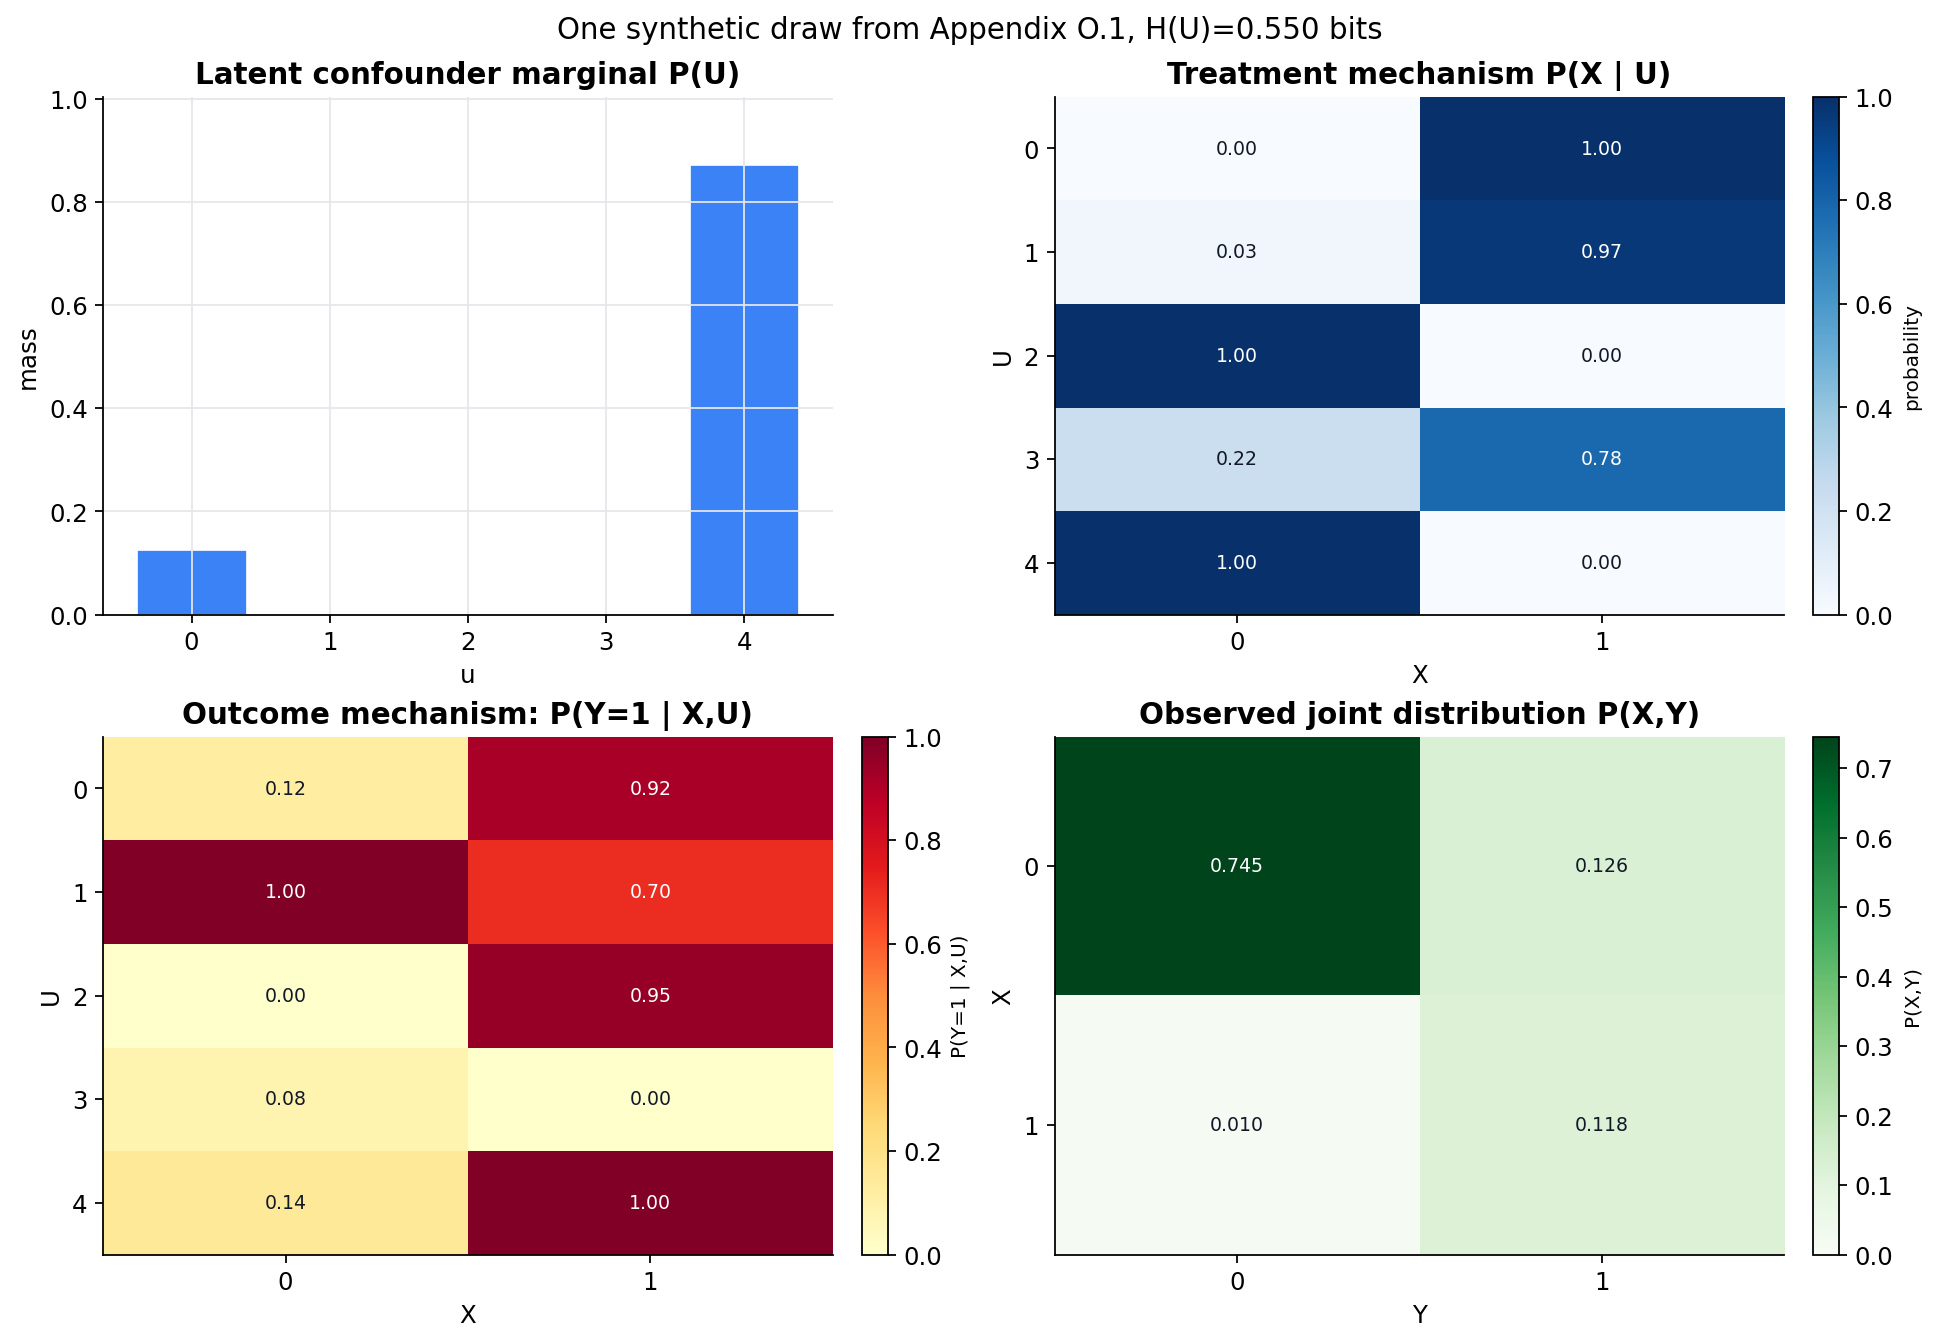

In [3]:

def draw_heatmap(ax, values, title, xlabel, ylabel, cmap, vmin=0.0, vmax=1.0, fmt=".2f", cbar_label="probability"):
    im = ax.imshow(values, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    ax.grid(False)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticks(np.arange(values.shape[1]))
    ax.set_yticks(np.arange(values.shape[0]))
    threshold = vmin + 0.58 * (vmax - vmin)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            color = "white" if values[i, j] > threshold else "#111827"
            ax.text(j, i, format(values[i, j], fmt), ha="center", va="center", fontsize=8.5, color=color)
    cbar = ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(cbar_label, fontsize=9)
    return im


def plot_generation_example(data, idx=None):
    if idx is None:
        idx = int(np.argmin(np.abs(data["h_u"] - 0.55)))

    p_u = data["p_u"][idx]
    p_x_u = data["p_x_given_u"][idx]
    p_y_xu = data["p_y_given_xu"][idx]
    p_xy = data["p_xy"][idx]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

    ax = axes[0, 0]
    ax.bar(np.arange(DU), p_u, color="#3b82f6", edgecolor="white", linewidth=1.2)
    ax.set_title("Latent confounder marginal P(U)")
    ax.set_xlabel("u")
    ax.set_ylabel("mass")
    ax.set_ylim(0, max(0.55, p_u.max() * 1.15))

    draw_heatmap(
        axes[0, 1],
        p_x_u,
        title="Treatment mechanism P(X | U)",
        xlabel="X",
        ylabel="U",
        cmap="Blues",
        cbar_label="probability",
    )

    draw_heatmap(
        axes[1, 0],
        p_y_xu[:, :, 1],
        title="Outcome mechanism: P(Y=1 | X,U)",
        xlabel="X",
        ylabel="U",
        cmap="YlOrRd",
        cbar_label="P(Y=1 | X,U)",
    )

    draw_heatmap(
        axes[1, 1],
        p_xy,
        title="Observed joint distribution P(X,Y)",
        xlabel="Y",
        ylabel="X",
        cmap="Greens",
        vmin=0,
        vmax=max(0.5, p_xy.max()),
        fmt=".3f",
        cbar_label="P(X,Y)",
    )

    fig.suptitle(f"One synthetic draw from Appendix O.1, H(U)={entropy_bits(p_u):.3f} bits", y=1.03)
    return idx, fig

example_idx, fig_generation = plot_generation_example(data)
save_figure(fig_generation, "o1_data_generation_example")
example_idx


Simulation.ipynb:cell_5:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


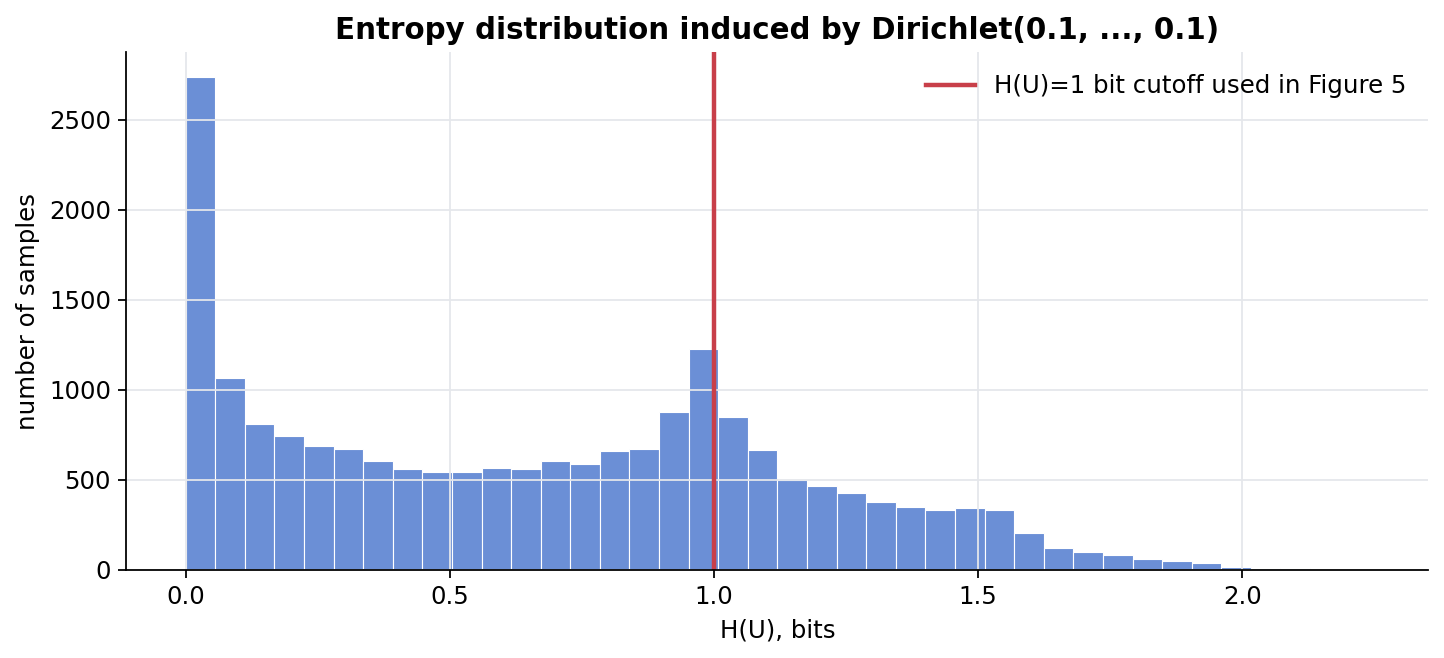

In [4]:

fig, ax = plt.subplots(figsize=(10.5, 4.2))
ax.hist(data["h_u"], bins=40, color="#6b8fd6", edgecolor="white", linewidth=0.5)
ax.axvline(1.0, color="#c83f49", linewidth=2, label="H(U)=1 bit cutoff used in Figure 5")
ax.set_title("Entropy distribution induced by Dirichlet(0.1, ..., 0.1)")
ax.set_xlabel("H(U), bits")
ax.set_ylabel("number of samples")
ax.legend(frameon=False)
save_figure(fig, "o1_entropy_distribution")
plt.show()



## 2. Our method: exact subset-sum criterion and tight bound

For a query `P(y | do(x))`, Theorem 6 says that the tight lower endpoint degenerates to the vanilla lower endpoint iff some subset of confounder masses falls in
\[
[P(x,y), P(x)].
\]
The tight upper endpoint degenerates to the vanilla upper endpoint iff some subset mass falls in
\[
[P(\neg x), 1-P(x,\neg y)].
\]

Thus the exact non-vanilla judgement reduces to a subset-sum feasibility problem over the masses of `P(U)`. This is the piece that the entropy baseline throws away: entropy is one scalar, while the tight criterion uses the whole subset-sum spectrum.


In [ ]:
def subset_mask_matrix(du: int = DU) -> np.ndarray:
    integers = np.arange(1 << du, dtype=np.int64)[:, None]
    bits = (integers >> np.arange(du, dtype=np.int64)) & 1
    return bits.astype(float)


SUBSET_MASK = subset_mask_matrix(DU)


def all_subset_sums(p_u: np.ndarray) -> np.ndarray:
    p_u = np.asarray(p_u, dtype=float)
    if p_u.ndim == 1:
        return subset_mask_matrix(p_u.shape[0]) @ p_u
    if p_u.ndim == 2:
        return p_u @ subset_mask_matrix(p_u.shape[1]).T
    raise ValueError("p_u must be a 1D or 2D array.")


def has_subset_sum_in_interval(subset_sums: np.ndarray, lower, upper, tol: float = 1e-10):
    subset_sums = np.asarray(subset_sums, dtype=float)
    lower = np.asarray(lower, dtype=float)
    upper = np.asarray(upper, dtype=float)
    if subset_sums.ndim == 1:
        return bool(((subset_sums >= float(lower) - tol) & (subset_sums <= float(upper) + tol)).any())
    return ((subset_sums >= lower[:, None] - tol) & (subset_sums <= upper[:, None] + tol)).any(axis=1)


# Backward-compatible alias used by earlier explanatory cells.
in_interval_any = has_subset_sum_in_interval


def ours_event_nonvanilla_by_theorem6(p_u: np.ndarray, p_xy: np.ndarray):
    subset_sums = all_subset_sums(p_u)
    out = {}
    for x, y in product([0, 1], [0, 1]):
        px = p_xy[:, x, :].sum(axis=1)
        pxy = p_xy[:, x, y]
        px_not_y = p_xy[:, x, 1 - y]
        p_not_x = 1.0 - px

        lower_vanilla = has_subset_sum_in_interval(subset_sums, pxy, px)
        upper_vanilla = has_subset_sum_in_interval(subset_sums, p_not_x, 1.0 - px_not_y)
        out[(x, y)] = {
            "lower_vanilla": lower_vanilla,
            "upper_vanilla": upper_vanilla,
            "nonvanilla": ~(lower_vanilla & upper_vanilla),
        }
    return out, subset_sums


ours_nonvanilla_matrix = ours_event_nonvanilla_by_theorem6


def interval_distance_to_subset_spectrum(subset_sums_1d: np.ndarray, lower: float, upper: float) -> float:
    subset_sums_1d = np.asarray(subset_sums_1d, dtype=float)
    if has_subset_sum_in_interval(subset_sums_1d, lower, upper, tol=1e-12):
        return 0.0
    return float(np.minimum(np.abs(subset_sums_1d - lower), np.abs(subset_sums_1d - upper)).min())


def _subset_sums_excluding(p_u: np.ndarray, excluded: int) -> np.ndarray:
    keep = [i for i in range(len(p_u)) if i != excluded]
    if not keep:
        return np.array([0.0])
    mask = subset_mask_matrix(len(keep))
    return np.asarray(p_u)[keep] @ mask.T


def _pmin_pmax_excluding(p_u: np.ndarray, excluded: int, lower: float, upper: float):
    sums = _subset_sums_excluding(p_u, excluded)
    feasible = sums[(sums >= lower - 1e-12) & (sums <= upper + 1e-12)]
    if feasible.size == 0:
        return []
    return [float(feasible.min()), float(feasible.max())]


def _b_prime(p_u: np.ndarray, px: float, pxy: float, px_not_y: float) -> float:
    # Theorem 10: exact enumeration over the 2^d subset masses of P(U \ {t}).
    best = math.inf
    for t, p_t in enumerate(p_u):
        if p_t + 1e-12 < px_not_y:
            continue
        lo = max(0.0, px - p_t)
        hi = pxy
        for s in _pmin_pmax_excluding(p_u, t, lo, hi):
            denom = px - s
            if denom <= 1e-12:
                continue
            candidate = s + p_t * (pxy - s) / denom
            best = min(best, candidate)
    return best


def ours_tight_event_bound_by_theorem10(p_u: np.ndarray, p_xy_2x2: np.ndarray, x: int, y: int):
    p_u = np.asarray(p_u, dtype=float)
    p_xy_2x2 = np.asarray(p_xy_2x2, dtype=float)
    subset_sums = all_subset_sums(p_u)

    px = float(p_xy_2x2[x, :].sum())
    pxy = float(p_xy_2x2[x, y])
    px_not_y = float(p_xy_2x2[x, 1 - y])
    p_not_x = 1.0 - px

    lower_is_vanilla = has_subset_sum_in_interval(subset_sums, pxy, px, tol=1e-12)
    upper_is_vanilla = has_subset_sum_in_interval(subset_sums, p_not_x, 1.0 - px_not_y, tol=1e-12)

    if lower_is_vanilla:
        lb = pxy
    else:
        lb = _b_prime(p_u, px=px, pxy=pxy, px_not_y=px_not_y)

    if upper_is_vanilla:
        ub = pxy + p_not_x
    else:
        # UB_{x,y} = 1 - B'(P(U); x, not y).
        ub = 1.0 - _b_prime(p_u, px=px, pxy=px_not_y, px_not_y=pxy)

    return float(np.clip(lb, 0, 1)), float(np.clip(ub, 0, 1))


ours_tight_bounds_single = ours_tight_event_bound_by_theorem10

ours_query, subset_sums = ours_event_nonvanilla_by_theorem6(data["p_u"], data["p_xy"])
print("Subset sums per sample:", subset_sums.shape[1])
print("Example query non-vanilla share, P(Y=1|do(X=1)):", ours_query[(1, 1)]["nonvanilla"].mean().round(3))


## 3. Baseline: Jiang et al. (2023) entropy method

For binary `X,Y`, Jiang et al. bound the query by imposing an entropy/mutual-information constraint on the counterfactual variable `Y_x`. In this binary setting the optimization reduces to one scalar:
\[
P(Y_x=y)=P(x,y)+rP(\neg x),\quad r=P(Y_x=y\mid \neg x),\quad r\in[0,1],
\]
with
\[
I(Y_x;X) \le H(U).
\]
The Tian-Pearl lower/upper endpoints correspond to `r=0` and `r=1`. Therefore the baseline is non-vanilla exactly when the observed entropy is below the entropy threshold needed to allow those endpoint constructions.


In [6]:

def hb_bits(p):
    p = np.clip(np.asarray(p, dtype=float), EPS, 1.0 - EPS)
    return -(p * np.log2(p) + (1.0 - p) * np.log2(1.0 - p))


def binary_mi_bits(px, q, r):
    px = np.asarray(px, dtype=float)
    q = np.asarray(q, dtype=float)
    r = np.asarray(r, dtype=float)
    marginal = px * q + (1.0 - px) * r
    return hb_bits(marginal) - px * hb_bits(q) - (1.0 - px) * hb_bits(r)


def jiang_entropy_threshold(px, q):
    return np.maximum(binary_mi_bits(px, q, 0.0), binary_mi_bits(px, q, 1.0))


def jiang_nonvanilla_matrix(p_xy: np.ndarray, h_u_bits: np.ndarray):
    out = {}
    for x, y in product([0, 1], [0, 1]):
        px = p_xy[:, x, :].sum(axis=1)
        q = p_xy[:, x, y] / np.clip(px, EPS, None)
        threshold = jiang_entropy_threshold(px, q)
        out[(x, y)] = {
            "threshold": threshold,
            "nonvanilla": h_u_bits < threshold - 1e-12,
        }
    return out


def _bisect_boundary(px, q, theta, side):
    def mi(r):
        return float(binary_mi_bits(px, q, r))

    if side == "left":
        if theta >= mi(0.0) - 1e-12:
            return 0.0
        lo, hi = 0.0, float(q)
        for _ in range(80):
            mid = 0.5 * (lo + hi)
            if mi(mid) > theta:
                lo = mid
            else:
                hi = mid
        return hi

    if theta >= mi(1.0) - 1e-12:
        return 1.0
    lo, hi = float(q), 1.0
    for _ in range(80):
        mid = 0.5 * (lo + hi)
        if mi(mid) <= theta:
            lo = mid
        else:
            hi = mid
    return lo


def jiang_bounds_single(p_xy_2x2: np.ndarray, h_u_bits: float, x: int, y: int):
    px = float(p_xy_2x2[x, :].sum())
    pxy = float(p_xy_2x2[x, y])
    q = pxy / max(px, EPS)
    r_min = _bisect_boundary(px, q, h_u_bits, side="left")
    r_max = _bisect_boundary(px, q, h_u_bits, side="right")
    lb = pxy + r_min * (1.0 - px)
    ub = pxy + r_max * (1.0 - px)
    return float(np.clip(lb, 0, 1)), float(np.clip(ub, 0, 1))


jiang_query = jiang_nonvanilla_matrix(data["p_xy"], data["h_u"])
print("Baseline example query non-vanilla share, P(Y=1|do(X=1)):", jiang_query[(1, 1)]["nonvanilla"].mean().round(3))


Baseline example query non-vanilla share, P(Y=1|do(X=1)): 0.311


## 4. Figure 5 reproduction

A sample is counted as **non-vanilla** if at least one of the four binary queries
\[
P(Y=y\mid do(X=x)),\quad x,y\in\{0,1\},
\]
has a non-vanilla bound.

The baseline only sees `H(U)`, while ours sees the complete `P(U)` through its subset-sum spectrum. Consequently, ours / ground truth should identify at least as many non-vanilla cases, with the gap especially visible at larger entropy.

This entropy-binned experiment fixes `d_u=5` and evaluates the information loss of entropy summaries. It is not a test of the large-`d_u` degeneration result in Proposition 9.

In [ ]:
def summarize_figure5(data, ours_query, jiang_query):
    h = data["h_u"]
    keep = h <= 1.0 + 1e-12

    ours_any_nonvanilla = np.zeros(h.shape[0], dtype=bool)
    baseline_any_nonvanilla = np.zeros(h.shape[0], dtype=bool)
    for query in product([0, 1], [0, 1]):
        ours_any_nonvanilla |= ours_query[query]["nonvanilla"]
        baseline_any_nonvanilla |= jiang_query[query]["nonvanilla"]

    loss_ours_nonvanilla_baseline_vanilla = ours_any_nonvanilla & ~baseline_any_nonvanilla

    bins = np.linspace(0, 1, 11)
    bin_id = np.searchsorted(bins, h[keep], side="right") - 1
    bin_id = np.clip(bin_id, 0, len(bins) - 2)
    labels = [f"[{bins[i]:.1f},{bins[i+1]:.1f}]" for i in range(len(bins) - 1)]

    rows = []
    kept_indices = np.flatnonzero(keep)
    for i, label in enumerate(labels):
        idx = kept_indices[bin_id == i]
        total_samples = len(idx)
        baseline_nonvanilla = int(baseline_any_nonvanilla[idx].sum())
        ours_nonvanilla = int(ours_any_nonvanilla[idx].sum())
        loss = int(loss_ours_nonvanilla_baseline_vanilla[idx].sum())
        rows.append({
            "entropy_bin": label,
            "total_samples": total_samples,
            "baseline_nonvanilla": baseline_nonvanilla,
            "ours_nonvanilla": ours_nonvanilla,
            "loss_ours_nonvanilla_baseline_vanilla": loss,
            "loss_rate_among_ours": (loss / ours_nonvanilla) if ours_nonvanilla else np.nan,
        })

    summary = pd.DataFrame(rows)
    flags = {
        "keep": keep,
        "ours_any_nonvanilla": ours_any_nonvanilla,
        "baseline_any_nonvanilla": baseline_any_nonvanilla,
        "loss_ours_nonvanilla_baseline_vanilla": loss_ours_nonvanilla_baseline_vanilla,
    }
    return summary, flags


fig5_summary, flags = summarize_figure5(data, ours_query, jiang_query)
fig5_summary.to_csv(TABLE_DIR / "synthetic_entropy_summary.csv", index=False)

fig5_summary_latex_df = fig5_summary.rename(columns={
    "entropy_bin": "Entropy bin",
    "total_samples": "Total samples",
    "baseline_nonvanilla": "Baseline non-vanilla",
    "ours_nonvanilla": "Our non-vanilla",
    "loss_ours_nonvanilla_baseline_vanilla": "Ours non-vanilla / baseline vanilla",
    "loss_rate_among_ours": "Loss rate among ours",
}).copy()
fig5_summary_latex_df["Loss rate among ours"] = fig5_summary_latex_df["Loss rate among ours"].map(
    lambda x: "--" if pd.isna(x) else f"{100*x:.1f}%"
)
figure5_summary_latex = save_latex_table(
    fig5_summary_latex_df,
    "figure5_summary",
    caption=f"Simulation summary for Figure 5 (N={N_SAMPLES:,}, d_u={DU}).",
    label="tab:figure5-summary",
)
print(figure5_summary_latex)

In [ ]:
def plot_figure5(summary):
    labels = summary["entropy_bin"].tolist()
    x = np.arange(len(labels))

    fig, ax = plt.subplots(figsize=(13, 6), constrained_layout=True)

    ax.bar(x, summary["total_samples"], width=0.78, color=PALETTE["total"], edgecolor="white", label="Total samples")
    ax.bar(
        x - 0.18,
        summary["baseline_nonvanilla"],
        width=0.34,
        color=PALETTE["baseline"],
        edgecolor="white",
        linewidth=0.8,
        label="Non-vanilla PI bound (entropy baseline)",
    )
    ax.bar(
        x + 0.18,
        summary["ours_nonvanilla"],
        width=0.34,
        color=PALETTE["ours"],
        edgecolor="white",
        linewidth=0.8,
        label="Non-vanilla PI bound (ours / ground truth)",
    )

    for xi, row in summary.iterrows():
        loss = int(row["loss_ours_nonvanilla_baseline_vanilla"])
        if loss > 0:
            ax.text(
                xi + 0.18,
                row["ours_nonvanilla"] + max(summary["total_samples"].max() * 0.015, 8),
                f"+{loss}",
                ha="center",
                va="bottom",
                fontsize=8.5,
                color=PALETTE["loss"],
                fontweight="bold",
            )

    mode_label = "FAST" if FAST_MODE else "FULL"
    ax.set_title(f"Figure 5: sample-level non-vanilla counts (N={N_SAMPLES:,}, {mode_label}_MODE; H(U)=1 cutoff)")
    ax.set_xlabel("Confounder entropy H(U) (bits)")
    ax.set_ylabel("Number of samples")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=25, ha="right")
    ax.legend(frameon=False, ncol=1, loc="upper right")
    ax.margins(x=0.01)
    return fig, ax


fig_figure5, ax_figure5 = plot_figure5(fig5_summary)
save_figure(fig_figure5, "figure5_nonvanilla_counts")
plt.show()

In [ ]:
def plot_information_loss(summary):
    labels = summary["entropy_bin"].tolist()
    x = np.arange(len(labels))
    rate = summary["loss_rate_among_ours"].to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(13, 4.8), constrained_layout=True)
    bars = ax.bar(
        x,
        summary["loss_ours_nonvanilla_baseline_vanilla"],
        width=0.62,
        color=PALETTE["loss"],
        edgecolor="white",
        linewidth=0.8,
        label="Ours non-vanilla but entropy baseline vanilla",
    )
    mode_label = "FAST" if FAST_MODE else "FULL"
    ax.set_title(f"Information loss of the entropy baseline (N={N_SAMPLES:,}, {mode_label}_MODE)")
    ax.set_xlabel("Confounder entropy H(U) (bits)")
    ax.set_ylabel("Lost non-vanilla samples")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=25, ha="right")

    ax2 = ax.twinx()
    ax2.plot(x, rate * 100, color="#111827", marker="o", linewidth=2, label="Loss rate among ours")
    ax2.set_ylabel("Loss rate among ours (%)")
    ax2.set_ylim(0, max(5, np.nanmax(rate * 100) * 1.25))

    lines, line_labels = ax.get_legend_handles_labels()
    lines2, line_labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines + lines2, line_labels + line_labels2, frameon=False, loc="upper left")

    for bar, pct in zip(bars, rate * 100):
        if bar.get_height() > 0 and np.isfinite(pct):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(summary["loss_ours_nonvanilla_baseline_vanilla"].max() * 0.02, 1),
                f"{pct:.0f}%",
                ha="center",
                va="bottom",
                fontsize=8.5,
                color="#111827",
            )
    return fig, ax


fig_info_loss, ax_info_loss = plot_information_loss(fig5_summary)
save_figure(fig_info_loss, "information_loss_entropy_baseline")
plt.show()


## 5. One concrete information-loss example

The next cell picks a draw where the tight subset-sum method detects a non-vanilla bound but Jiang's entropy-only method does not. The subset-sum spectrum plot shows the exact object used by our method: if the subset masses avoid one of the target intervals, the corresponding endpoint must improve over the vanilla endpoint.


In [10]:

def find_loss_example(data, ours_query, jiang_query):
    for query in product([0, 1], [0, 1]):
        mask = ours_query[query]["nonvanilla"] & ~jiang_query[query]["nonvanilla"] & (data["h_u"] <= 1.0)
        if mask.any():
            idx = int(np.flatnonzero(mask)[0])
            return idx, query
    # Fallback: any tight non-vanilla example.
    for query in product([0, 1], [0, 1]):
        mask = ours_query[query]["nonvanilla"] & (data["h_u"] <= 1.0)
        if mask.any():
            idx = int(np.flatnonzero(mask)[0])
            return idx, query
    return 0, (1, 1)


loss_idx, loss_query = find_loss_example(data, ours_query, jiang_query)
loss_idx, loss_query, data["h_u"][loss_idx]


(3, (0, 0), np.float64(0.13836184865699563))

Simulation.ipynb:cell_16:38: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


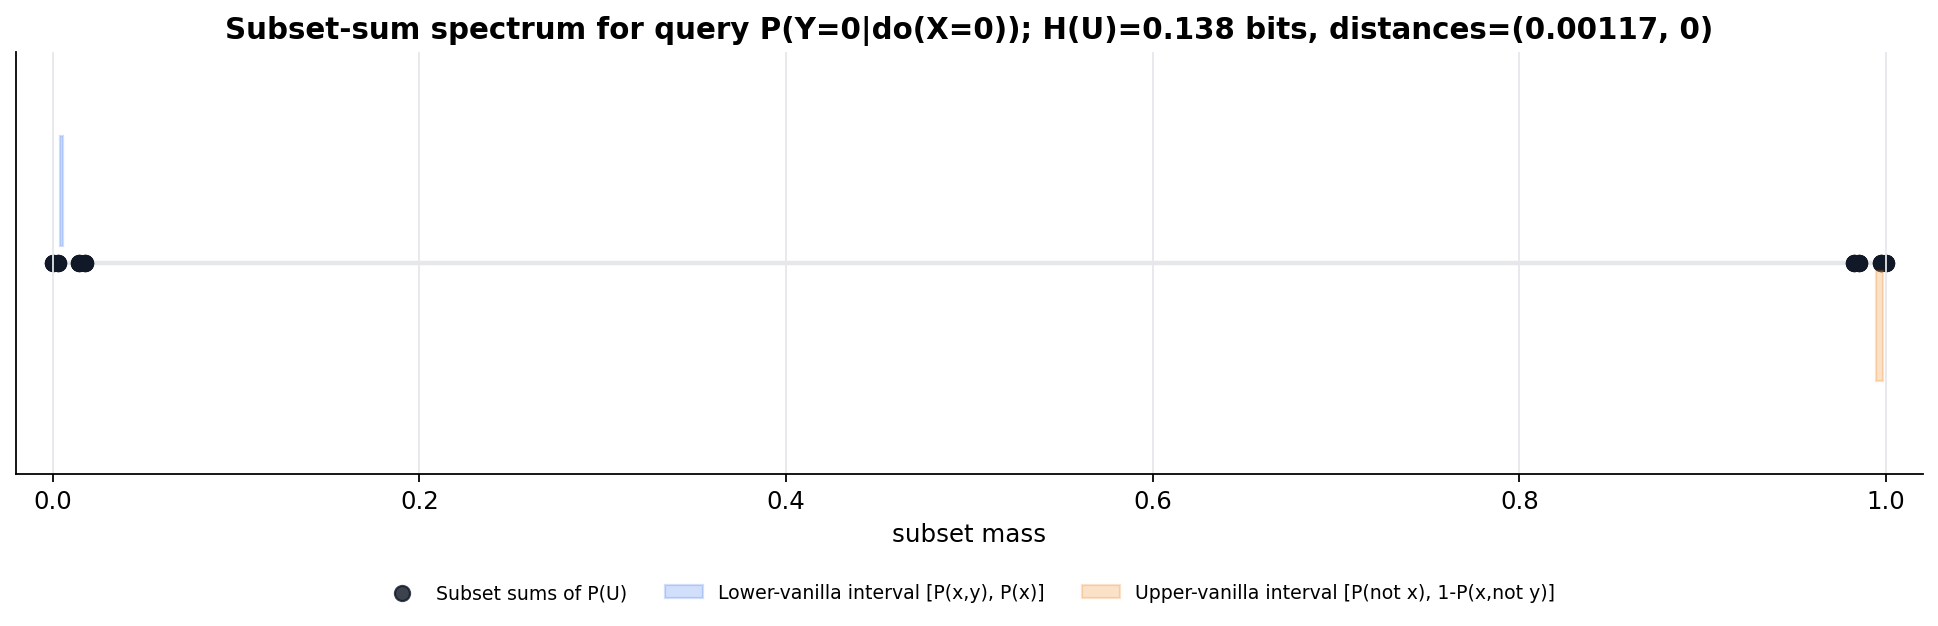

In [11]:

def plot_subset_spectrum_example(data, idx, query):
    x, y = query
    p_u = data["p_u"][idx]
    p_xy = data["p_xy"][idx]
    sums = np.sort(all_subset_sums(p_u[None, :])[0])

    px = p_xy[x, :].sum()
    pxy = p_xy[x, y]
    px_not_y = p_xy[x, 1 - y]
    p_not_x = 1.0 - px
    lower_interval = (pxy, px)
    upper_interval = (p_not_x, 1.0 - px_not_y)

    fig, ax = plt.subplots(figsize=(12, 3.8), constrained_layout=True)
    ax.scatter(sums, np.zeros_like(sums), s=46, color="#111827", alpha=0.82, label="Subset sums of P(U)")
    ax.hlines(0, 0, 1, color="#e5e7eb", linewidth=2, zorder=0)

    ax.axvspan(*lower_interval, ymin=0.54, ymax=0.80, color="#2f6fed", alpha=0.22, label="Lower-vanilla interval [P(x,y), P(x)]")
    ax.axvspan(*upper_interval, ymin=0.22, ymax=0.48, color="#ef8a22", alpha=0.25, label="Upper-vanilla interval [P(not x), 1-P(x,not y)]")

    d_lower = interval_distance_to_subset_spectrum(sums, *lower_interval)
    d_upper = interval_distance_to_subset_spectrum(sums, *upper_interval)

    ax.set_xlim(-0.02, 1.02)
    ax.set_yticks([])
    ax.set_xlabel("subset mass")
    ax.set_title(
        f"Subset-sum spectrum for query P(Y={y}|do(X={x})); "
        f"H(U)={data['h_u'][idx]:.3f} bits, distances=({d_lower:.3g}, {d_upper:.3g})"
    )
    ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=3, fontsize=8.5)
    return fig, ax


fig_subset_spectrum, ax_subset_spectrum = plot_subset_spectrum_example(data, loss_idx, loss_query)
save_figure(fig_subset_spectrum, "o1_subset_spectrum_example")
plt.show()


In [12]:
def bound_table_for_sample(data, idx):
    rows = []
    p_u = data["p_u"][idx]
    p_xy = data["p_xy"][idx]
    h = float(data["h_u"][idx])
    truth = data["p_y_do_x"][idx]

    for x, y in product([0, 1], [0, 1]):
        px = float(p_xy[x, :].sum())
        pxy = float(p_xy[x, y])
        tp = (pxy, pxy + 1.0 - px)
        jb = jiang_bounds_single(p_xy, h, x, y)
        ob = ours_tight_bounds_single(p_u, p_xy, x, y)
        rows.append({
            "query": f"P(Y={y}|do(X={x}))",
            "truth_from_DGP": truth[x, y],
            "Tian_Pearl": f"[{tp[0]:.3f}, {tp[1]:.3f}]",
            "Jiang_entropy": f"[{jb[0]:.3f}, {jb[1]:.3f}]",
            "ours_tight": f"[{ob[0]:.3f}, {ob[1]:.3f}]",
            "TP_width": tp[1] - tp[0],
            "Jiang_width": jb[1] - jb[0],
            "ours_width": ob[1] - ob[0],
        })
    return pd.DataFrame(rows)


example_bounds = bound_table_for_sample(data, loss_idx)
example_bounds_latex_df = example_bounds.rename(columns={
    "query": "Query",
    "truth_from_DGP": "DGP truth",
    "Tian_Pearl": "Tian--Pearl",
    "Jiang_entropy": "Jiang entropy",
    "ours_tight": "Our tight bound",
    "TP_width": "Tian--Pearl width",
    "Jiang_width": "Jiang width",
    "ours_width": "Our width",
}).copy()
for col in ["DGP truth", "Tian--Pearl width", "Jiang width", "Our width"]:
    example_bounds_latex_df[col] = example_bounds_latex_df[col].map(lambda x: f"{x:.3f}")
o1_example_bounds_latex = save_latex_table(
    example_bounds_latex_df,
    "o1_example_bounds",
    caption="Bounds for one simulation draw where the entropy baseline loses subset-sum information.",
    label="tab:o1-example-bounds",
)
print(o1_example_bounds_latex)

Simulation.ipynb:cell_18:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


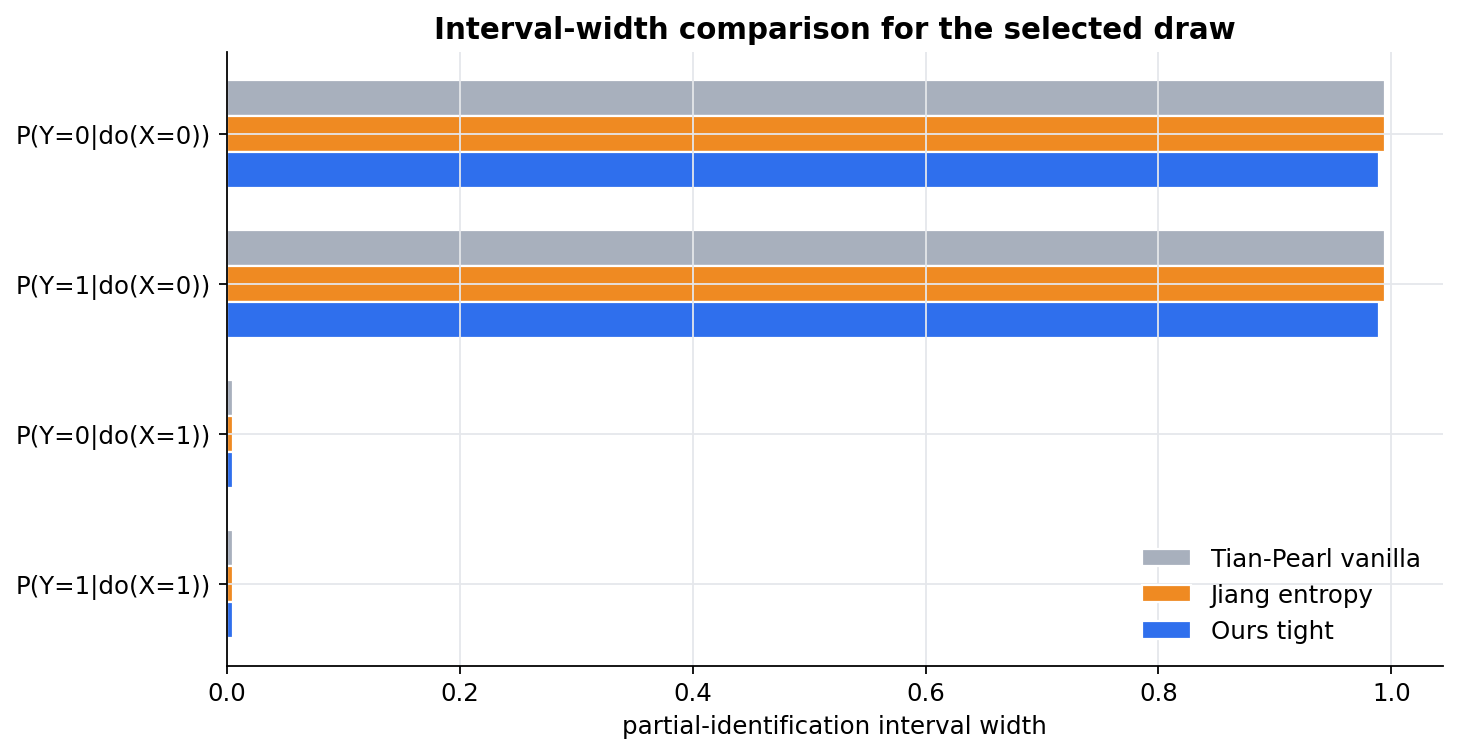

In [13]:

fig, ax = plt.subplots(figsize=(9, 4.6), constrained_layout=True)
queries = example_bounds["query"].tolist()
y = np.arange(len(queries))
bar_h = 0.24
series = [
    ("Tian-Pearl vanilla", example_bounds["TP_width"].to_numpy(), "#a8b0bd", -bar_h),
    ("Jiang entropy", example_bounds["Jiang_width"].to_numpy(), PALETTE["baseline"], 0.0),
    ("Ours tight", example_bounds["ours_width"].to_numpy(), PALETTE["ours"], bar_h),
]
for label, values, color, offset in series:
    ax.barh(y + offset, values, height=bar_h, color=color, edgecolor="white", label=label)
ax.set_yticks(y)
ax.set_yticklabels(queries)
ax.invert_yaxis()
ax.set_title("Interval-width comparison for the selected draw")
ax.set_xlabel("partial-identification interval width")
ax.set_ylabel("")
ax.legend(frameon=False, loc="lower right")
save_figure(fig, "o1_example_bound_widths")
plt.show()


## 6. Notes for paper-scale runs

- `FAST_MODE=True` runs `N_SAMPLES_FAST=20_000`; set `FAST_MODE=False` to run the full `N_SAMPLES_FULL=1_000_000` Monte Carlo.
- The entropy-binned Figure 5 experiment fixes `d_u=5` and measures the information loss from summarizing `P(U)` only by `H(U)` in bits. It is not a test of the large-`d_u` degeneration result in Proposition 9.
- The subset-sum part is exact for `d_u=5`, because all `2^5=32` subset masses are enumerated.
- The baseline implemented here is the binary specialization of Jiang et al. (2023): it uses the entropy threshold / scalar mutual-information constrained bound for each query. This is the fair comparison for Appendix O.1 because it gives the baseline exactly the information it assumes, `H(U)`, while our method receives the same generated sample's full marginal `P(U)`.

# Appendix O.2 Real-World Experiments

本节复现 Appendix O.2 的 INSURANCE 与 ADULT 实验，并重新生成 Table 6、Table 7。

数据与设置来自 Jiang et al. baseline 代码：

- INSURANCE: `X=this car cost`, `Y=property cost`, `U=accident`；
- ADULT: `X=relationship`, `Y=income`, `U=age`，age 按 65 岁二分。

`OUR BOUNDS` 使用本文 exact subset-sum TPI 重新计算，因此这里的结果比旧版表格更紧。

In [ ]:
from pathlib import Path
import contextlib
import io
import warnings
import textwrap

BASELINE_ROOT = PROJECT_ROOT / "_jiang23_baseline" / "Approximate-Causal-Effect-Identification-under-Weak-Confounding-main"
INSURANCE_SCRIPT = BASELINE_ROOT / "experiment_insurance_dataset.py"
ADULT_SCRIPT = BASELINE_ROOT / "experiment_adult_dataset.py"
ADULT_DATA = DATA_DIR / "adult.data"


def require_existing_path(path: Path):
    if not path.exists():
        raise FileNotFoundError(
            f"Cannot find {path}. Please place the file under data/ or update DATA_DIR."
        )
    return path


require_existing_path(INSURANCE_SCRIPT)
require_existing_path(ADULT_SCRIPT)
require_existing_path(ADULT_DATA)

print("Baseline code:", BASELINE_ROOT.relative_to(PROJECT_ROOT))
print("Adult data:", ADULT_DATA.relative_to(PROJECT_ROOT))

In [ ]:
def execute_baseline_prefix(script_path: Path, stop_marker: str):
    # Execute only Jiang et al.'s data-preparation prefix; this avoids requiring cvxpy.
    src = script_path.read_text(encoding="utf-8")
    src = src.replace("import cvxpy as cp\n", "")
    src = src.replace("np.loadtxt('adult.data', delimiter=',', dtype=str)", "np.loadtxt(ADULT_DATA, delimiter=',', dtype=str)")
    if stop_marker not in src:
        raise ValueError(f"Cannot find stop marker {stop_marker!r} in {script_path}.")
    prefix = src.split(stop_marker)[0]
    namespace = {"ADULT_DATA": str(ADULT_DATA)}
    with contextlib.redirect_stdout(io.StringIO()), warnings.catch_warnings():
        warnings.simplefilter("ignore")
        exec(compile(prefix, str(script_path), "exec"), namespace)
    return namespace


def event_binary_joint_from_pyx(pyx: np.ndarray, y: int, x: int) -> np.ndarray:
    # Return binary P(X_event, Y_event), rows X in {not x, x}, cols Y in {not y, y}.
    pyx = np.asarray(pyx, dtype=float)  # shape: outcome, treatment
    px = float(pyx[:, x].sum())
    py = float(pyx[y, :].sum())
    pxy = float(pyx[y, x])
    out = np.zeros((2, 2), dtype=float)
    out[1, 1] = pxy
    out[1, 0] = px - pxy
    out[0, 1] = py - pxy
    out[0, 0] = 1.0 - out.sum()
    return out


def tian_pearl_event_bound(pyx: np.ndarray, y: int, x: int):
    px = float(pyx[:, x].sum())
    pxy = float(pyx[y, x])
    return pxy, pxy + 1.0 - px


def jiang_entropy_event_bound(pyx: np.ndarray, h_u_bits: float, y: int, x: int):
    # Jiang et al.'s binary event specialization: it depends on P(X=x), P(Y=y|X=x), H(U).
    px = float(pyx[:, x].sum())
    pxy = float(pyx[y, x])
    q = pxy / max(px, EPS)
    r_min = _bisect_boundary(px, q, h_u_bits, side="left")
    r_max = _bisect_boundary(px, q, h_u_bits, side="right")
    return pxy + r_min * (1.0 - px), pxy + r_max * (1.0 - px)


def tight_event_bound_from_binary_recoding(p_u: np.ndarray, pyx: np.ndarray, y: int, x: int):
    p_xy_binary = event_binary_joint_from_pyx(pyx, y, x)
    return ours_tight_event_bound_by_theorem10(np.asarray(p_u, dtype=float), p_xy_binary, x=1, y=1)


ours_tight_event_bound = tight_event_bound_from_binary_recoding


def fmt_interval(interval, digits=3):
    lo, hi = interval
    threshold = 0.5 * 10 ** (-digits)

    def clean(z):
        if abs(z) < threshold:
            return 0.0
        if abs(z - 1.0) < threshold:
            return 1.0
        if abs(z + 1.0) < threshold:
            return -1.0
        return z

    lo = clean(float(lo))
    hi = clean(float(hi))
    return f"[{lo:.{digits}f}, {hi:.{digits}f}]"


def fmt_interval_raw(interval, digits=12):
    lo, hi = interval
    return f"[{float(lo):.{digits}f}, {float(hi):.{digits}f}]"


def interval_width(interval):
    return float(interval[1] - interval[0])

In [16]:

insurance_ns = execute_baseline_prefix(INSURANCE_SCRIPT, "eps = 0.2")
ins_pyx = insurance_ns["pPropcostThiscarcost"]
ins_p_u = insurance_ns["pAccident"]

adult_ns = execute_baseline_prefix(ADULT_SCRIPT, "for i in range(pIncomeRelation_HourEdu.shape[0]):")
adult_pyx_by_group = adult_ns["pIncomeRelation_HourEdu"]
adult_pu_by_group = adult_ns["pAge_HourEdu"]

print("INSURANCE P(U=Accident):", np.round(ins_p_u, 6), "H=", round(float(entropy_bits(ins_p_u)), 3))
print("ADULT P(U=Age | subgroup) shape:", adult_pu_by_group.shape)


INSURANCE P(U=Accident): [0.99  0.007 0.002 0.001] H= 0.092
ADULT P(U=Age | subgroup) shape: (2, 2, 2)


In [ ]:
INSURANCE_ROWS = [
    # row, subgroup, X label, Y label, y-index, x-index
    (1, "UNDER 5000 MILES, NORMAL", "100,000", "10,000", 0, 2),
    (2, "UNDER 5000 MILES, NORMAL", "100,000", "100,000", 2, 2),
    (3, "UNDER 5000 MILES, NORMAL", "100,000", "1,000,000", 3, 2),
    (4, "UNDER 5000 MILES, NORMAL", "1,000,000", "10,000", 0, 3),
    (5, "UNDER 5000 MILES, NORMAL", "1,000,000", "100,000", 2, 3),
    (6, "UNDER 5000 MILES, NORMAL", "1,000,000", "1,000,000", 3, 3),
]

ADULT_GROUPS = [
    ("BELOW HIGH SCHOOL, FULL-TIME", 1, 1),
    ("ABOVE HIGH SCHOOL, PART-TIME", 0, 0),
    ("ABOVE HIGH SCHOOL, FULL-TIME", 1, 0),
]
ADULT_ROWS = []
row_no = 1
for subgroup, hour_idx, edu_idx in ADULT_GROUPS:
    for y_label, y_idx in [("<=50K", 0), (">50K", 1)]:
        for x_label, x_idx in [("YES", 0), ("NO", 1)]:
            ADULT_ROWS.append((row_no, subgroup, x_label, y_label, y_idx, x_idx, hour_idx, edu_idx))
            row_no += 1


def build_table6():
    records = []

    for row, subgroup, x_label, y_label, y_idx, x_idx in INSURANCE_ROWS:
        h = float(entropy_bits(ins_p_u))
        jiang = jiang_entropy_event_bound(ins_pyx, h, y_idx, x_idx)
        tp = tian_pearl_event_bound(ins_pyx, y_idx, x_idx)
        ours = tight_event_bound_from_binary_recoding(ins_p_u, ins_pyx, y_idx, x_idx)
        records.append({
            "row": row,
            "dataset": "INSUR",
            "SUBGROUP": subgroup,
            "X": x_label,
            "Y": y_label,
            "U": "ACCI",
            "H(U)": h,
            "Baseline (Jiang et al., 2023)": jiang,
            "Baseline (Tian and Pearl, 2000)": tp,
            "OUR BOUNDS": ours,
        })

    for row, subgroup, x_label, y_label, y_idx, x_idx, hour_idx, edu_idx in ADULT_ROWS:
        pyx = adult_pyx_by_group[:, :, hour_idx, edu_idx]
        p_u = adult_pu_by_group[:, hour_idx, edu_idx]
        h = float(entropy_bits(p_u))
        jiang = jiang_entropy_event_bound(pyx, h, y_idx, x_idx)
        tp = tian_pearl_event_bound(pyx, y_idx, x_idx)
        ours = tight_event_bound_from_binary_recoding(p_u, pyx, y_idx, x_idx)
        records.append({
            "row": row,
            "dataset": "ADULT",
            "SUBGROUP": subgroup,
            "X": x_label,
            "Y": y_label,
            "U": "AGE",
            "H(U)": h,
            "Baseline (Jiang et al., 2023)": jiang,
            "Baseline (Tian and Pearl, 2000)": tp,
            "OUR BOUNDS": ours,
        })
    return pd.DataFrame(records)


table6_raw = build_table6()
table6 = table6_raw.copy()
for col in ["Baseline (Jiang et al., 2023)", "Baseline (Tian and Pearl, 2000)", "OUR BOUNDS"]:
    table6[col] = table6[col].map(fmt_interval)
table6["H(U)"] = table6["H(U)"].map(lambda z: f"{z:.3f}")

table6.to_csv(TABLE_DIR / "table6_event_bounds.csv", index=False)

table6_latex_df = table6.rename(columns={
    "row": "No.",
    "dataset": "Dataset",
    "SUBGROUP": "Subgroup",
    "H(U)": "H(U)",
    "Baseline (Jiang et al., 2023)": "Jiang et al. (2023)",
    "Baseline (Tian and Pearl, 2000)": "Tian--Pearl (2000)",
    "OUR BOUNDS": "Our bound",
}).copy()
table6_latex = save_latex_table(
    table6_latex_df,
    "table6_event_bounds",
    caption="Real-data event-level interventional probability bounds. Since the confounder support is small in these real-data recodings, we enumerate all subset masses and compute the event-level TPI bounds exactly.",
    label="tab:o2-table6",
)
print(table6_latex)

Simulation.ipynb:cell_25:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


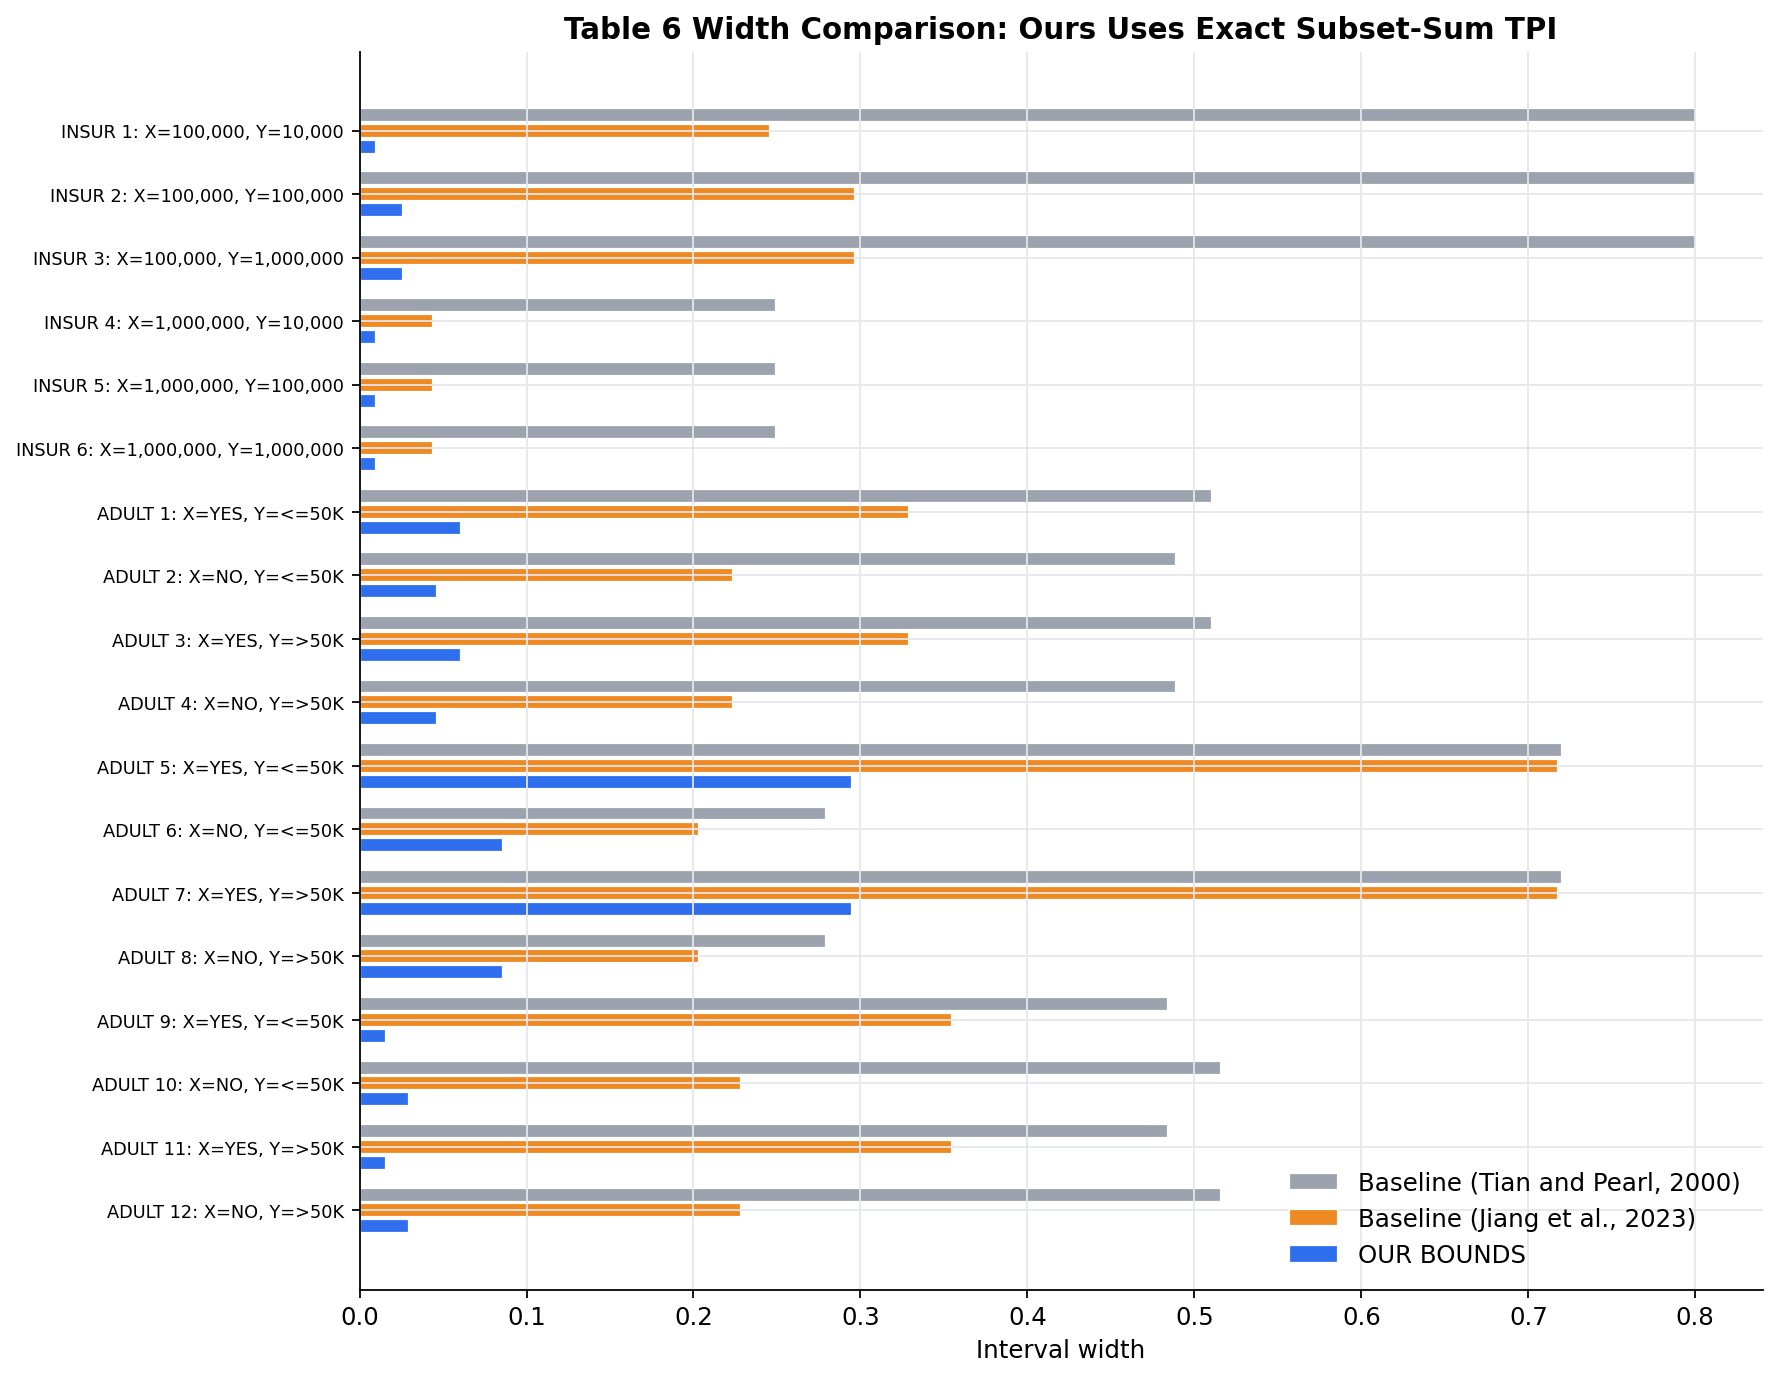

In [18]:

def plot_table6_widths(table6_raw):
    df = table6_raw.copy()
    for col in ["Baseline (Jiang et al., 2023)", "Baseline (Tian and Pearl, 2000)", "OUR BOUNDS"]:
        df[col + " width"] = df[col].map(interval_width)
    long = []
    for _, r in df.iterrows():
        label = f"{r['dataset']} {int(r['row'])}: X={r['X']}, Y={r['Y']}"
        for method, color in [
            ("Baseline (Tian and Pearl, 2000)", "#9ca3af"),
            ("Baseline (Jiang et al., 2023)", PALETTE["baseline"]),
            ("OUR BOUNDS", PALETTE["ours"]),
        ]:
            long.append({"label": label, "method": method, "width": r[method + " width"], "color": color})
    long = pd.DataFrame(long)

    labels = list(dict.fromkeys(long["label"]))
    y = np.arange(len(labels))
    fig, ax = plt.subplots(figsize=(11, 8.5), constrained_layout=True)
    offsets = {"Baseline (Tian and Pearl, 2000)": -0.25, "Baseline (Jiang et al., 2023)": 0.0, "OUR BOUNDS": 0.25}
    colors = {"Baseline (Tian and Pearl, 2000)": "#9ca3af", "Baseline (Jiang et al., 2023)": PALETTE["baseline"], "OUR BOUNDS": PALETTE["ours"]}
    for method in offsets:
        vals = [long[(long["label"] == lab) & (long["method"] == method)]["width"].iloc[0] for lab in labels]
        ax.barh(y + offsets[method], vals, height=0.22, color=colors[method], edgecolor="white", label=method)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("Interval width")
    ax.set_title("Table 6 Width Comparison: Ours Uses Exact Subset-Sum TPI")
    ax.legend(frameon=False, loc="lower right")
    save_figure(fig, "table6_width_comparison")
    return fig, ax

plot_table6_widths(table6_raw)
plt.show()


In [ ]:
def distance_to_interval_value(value: float, interval, tol: float = 1e-12) -> float:
    lo, hi = map(float, interval)
    if lo - tol <= value <= hi + tol:
        return 0.0
    return float(min(abs(value - lo), abs(value - hi)))


def compute_D(PU, interval) -> float:
    p_u = np.asarray(PU, dtype=float)
    subset_sums = all_subset_sums(p_u)
    lo, hi = map(float, interval)
    if has_subset_sum_in_interval(subset_sums, lo, hi, tol=1e-12):
        return 0.0
    return float(np.minimum(np.abs(subset_sums - lo), np.abs(subset_sums - hi)).min())


def compute_DATE(PU, interval0, interval1) -> float:
    p_u = np.asarray(PU, dtype=float)
    du = len(p_u)
    best = math.inf
    # Exact enumeration over all disjoint A0,A1: each atom is assigned to neither, A0, or A1.
    for code in range(3 ** du):
        tmp = code
        mass0 = 0.0
        mass1 = 0.0
        for i in range(du):
            assignment = tmp % 3
            tmp //= 3
            if assignment == 1:
                mass0 += p_u[i]
            elif assignment == 2:
                mass1 += p_u[i]
        dist = distance_to_interval_value(mass0, interval0) + distance_to_interval_value(mass1, interval1)
        best = min(best, dist)
    return float(best)


def _validate_prop12_inputs(p_xy, p_u, tol=1e-10):
    p_xy = np.asarray(p_xy, dtype=float)
    p_u = np.asarray(p_u, dtype=float)
    if p_xy.shape != (2, 2):
        raise ValueError(f"p_xy must have shape (2, 2); got {p_xy.shape}.")
    if p_u.ndim != 1:
        raise ValueError("p_u must be a one-dimensional probability vector.")
    if np.any(p_xy < -tol):
        raise ValueError(f"p_xy has negative entries: {p_xy}.")
    if np.any(p_u < -tol):
        raise ValueError(f"p_u has negative entries: {p_u}.")
    if not np.isclose(p_xy.sum(), 1.0, atol=tol):
        raise ValueError(f"p_xy must sum to 1; got {p_xy.sum():.12g}.")
    if not np.isclose(p_u.sum(), 1.0, atol=tol):
        raise ValueError(f"p_u must sum to 1; got {p_u.sum():.12g}.")
    p_xy = np.clip(p_xy, 0.0, None)
    p_xy = p_xy / p_xy.sum()
    p_u = np.clip(p_u, 0.0, None)
    p_u = p_u / p_u.sum()
    px = p_xy.sum(axis=1)
    if np.any(px <= tol):
        raise ValueError(f"Both P(X=0) and P(X=1) must be positive; got {px}.")
    return p_xy, p_u, px


def prop12_binary_ate_bound_with_diagnostics(p_xy, p_u, tol=1e-10):
    p_xy, p_u, px = _validate_prop12_inputs(p_xy, p_u, tol=tol)
    du = len(p_u)

    intervals = {(x, y): (float(p_xy[x, y]), float(px[x])) for x in [0, 1] for y in [0, 1]}
    Delta_11 = compute_D(p_u, intervals[(1, 1)])
    Delta_00 = compute_D(p_u, intervals[(0, 0)])
    Delta_01 = compute_D(p_u, intervals[(0, 1)])
    Delta_10 = compute_D(p_u, intervals[(1, 0)])
    Delta_ATE_L = compute_DATE(p_u, intervals[(0, 0)], intervals[(1, 1)])
    Delta_ATE_U = compute_DATE(p_u, intervals[(0, 1)], intervals[(1, 0)])

    alpha_0 = 1.0 / float(px[0])
    alpha_1 = 1.0 / float(px[1])

    ate_l_vanilla = -float(p_xy[1, 0]) - float(p_xy[0, 1])
    ate_u_vanilla = float(p_xy[1, 1]) + float(p_xy[0, 0])

    improve_L_1 = alpha_1 * Delta_11 ** 2 + alpha_0 * Delta_00 ** 2
    improve_L_2 = Delta_ATE_L ** 2 / du
    improve_L = max(improve_L_1, improve_L_2)

    improve_U_1 = alpha_0 * Delta_01 ** 2 + alpha_1 * Delta_10 ** 2
    improve_U_2 = Delta_ATE_U ** 2 / du
    improve_U = max(improve_U_1, improve_U_2)

    L_prop12_raw = ate_l_vanilla + improve_L
    U_prop12_raw = ate_u_vanilla - improve_U

    boundary_cells = [f"p{x}{y}" for x in [0, 1] for y in [0, 1] if p_xy[x, y] <= tol]
    warnings_list = []

    if L_prop12_raw > U_prop12_raw + tol:
        diagnostics = {
            "L_prop12_raw": L_prop12_raw,
            "U_prop12_raw": U_prop12_raw,
            "p_xy": p_xy.copy(),
            "p_u": p_u.copy(),
            "Delta_11": Delta_11,
            "Delta_00": Delta_00,
            "Delta_01": Delta_01,
            "Delta_10": Delta_10,
            "Delta_ATE_L": Delta_ATE_L,
            "Delta_ATE_U": Delta_ATE_U,
            "improve_L": improve_L,
            "improve_U": improve_U,
        }
        raise ValueError(f"Proposition 12 produced L > U beyond tolerance: {diagnostics}")
    if L_prop12_raw > U_prop12_raw:
        msg = "Proposition 12 produced L slightly above U within numerical tolerance; raw diagnostics are retained."
        warnings.warn(msg)
        warnings_list.append(msg)

    if L_prop12_raw < -1.0 - tol or U_prop12_raw > 1.0 + tol or L_prop12_raw > 1.0 + tol or U_prop12_raw < -1.0 - tol:
        raise ValueError(
            "Proposition 12 output is outside [-1, 1] beyond numerical tolerance: "
            f"[{L_prop12_raw}, {U_prop12_raw}]."
        )

    L_prop12 = L_prop12_raw
    U_prop12 = U_prop12_raw
    if L_prop12 < -1.0 or U_prop12 > 1.0 or L_prop12 > 1.0 or U_prop12 < -1.0:
        msg = "Clipped Proposition 12 interval to [-1, 1] for floating-point tolerance."
        warnings.warn(msg)
        warnings_list.append(msg)
        L_prop12 = float(np.clip(L_prop12, -1.0, 1.0))
        U_prop12 = float(np.clip(U_prop12, -1.0, 1.0))

    diagnostics = {
        "P_X0": float(px[0]),
        "P_X1": float(px[1]),
        "ATE_L_vanilla": ate_l_vanilla,
        "ATE_U_vanilla": ate_u_vanilla,
        "Delta_11": Delta_11,
        "Delta_00": Delta_00,
        "Delta_01": Delta_01,
        "Delta_10": Delta_10,
        "Delta_ATE_L": Delta_ATE_L,
        "Delta_ATE_U": Delta_ATE_U,
        "improve_L_1": improve_L_1,
        "improve_L_2": improve_L_2,
        "improve_L": improve_L,
        "improve_U_1": improve_U_1,
        "improve_U_2": improve_U_2,
        "improve_U": improve_U,
        "L_prop12_unclipped": L_prop12_raw,
        "U_prop12_unclipped": U_prop12_raw,
        "boundary_case": ";".join(boundary_cells),
        "prop12_warnings": "; ".join(warnings_list),
    }
    return (float(L_prop12), float(U_prop12)), diagnostics


def prop12_binary_ate_bound(p_xy, p_u):
    interval, _ = prop12_binary_ate_bound_with_diagnostics(p_xy, p_u)
    return interval


def binary_ate_joint_from_pyx(pyx: np.ndarray, y_idx: int, treated_x_idx: int, control_x_idx: int, normalize: bool = True) -> np.ndarray:
    # Return p_xy[x, y] with x=1 treated, x=0 control, y=1{Y=y_idx}.
    pyx = np.asarray(pyx, dtype=float)
    out = np.zeros((2, 2), dtype=float)
    out[0, 1] = float(pyx[y_idx, control_x_idx])
    out[0, 0] = float(pyx[:, control_x_idx].sum() - pyx[y_idx, control_x_idx])
    out[1, 1] = float(pyx[y_idx, treated_x_idx])
    out[1, 0] = float(pyx[:, treated_x_idx].sum() - pyx[y_idx, treated_x_idx])
    if normalize:
        total = out.sum()
        if total <= EPS:
            raise ValueError("Selected binary treatment levels have zero observed mass.")
        out = out / total
    return out


def tian_pearl_binary_event_bound(p_xy: np.ndarray, x: int, y: int):
    p_xy = np.asarray(p_xy, dtype=float)
    px = float(p_xy[x, :].sum())
    pxy = float(p_xy[x, y])
    return pxy, pxy + 1.0 - px


def jiang_entropy_binary_event_bound(p_xy: np.ndarray, h_u_bits: float, x: int, y: int):
    p_xy = np.asarray(p_xy, dtype=float)
    px = float(p_xy[x, :].sum())
    pxy = float(p_xy[x, y])
    q = pxy / max(px, EPS)
    r_min = _bisect_boundary(px, q, h_u_bits, side="left")
    r_max = _bisect_boundary(px, q, h_u_bits, side="right")
    return pxy + r_min * (1.0 - px), pxy + r_max * (1.0 - px)


def signed_ate_interval_from_event_bounds(q1_interval, q0_interval):
    return float(q1_interval[0] - q0_interval[1]), float(q1_interval[1] - q0_interval[0])


def binary_ate_interval_via_event_bounds(p_xy: np.ndarray, p_u: np.ndarray, h_u_bits: float, method: str):
    if method == "tian_pearl":
        bound_fn = lambda x: tian_pearl_binary_event_bound(p_xy, x=x, y=1)
    elif method == "jiang":
        bound_fn = lambda x: jiang_entropy_binary_event_bound(p_xy, h_u_bits, x=x, y=1)
    elif method == "ours_table6":
        bound_fn = lambda x: ours_tight_event_bound_by_theorem10(p_u, p_xy, x=x, y=1)
    else:
        raise ValueError(f"Unknown method: {method}")
    q1 = bound_fn(1)
    q0 = bound_fn(0)
    return signed_ate_interval_from_event_bounds(q1, q0)

In [ ]:
TABLE7_BINARY_ATE_SPECS = []

# INSURANCE original Table 7 same-X signed outcome contrasts are not binary ATEs.
# We therefore reconstruct INSURANCE rows as treatment contrasts for fixed outcome events.
for y_label, y_idx in [("10,000", 0), ("100,000", 2), ("1,000,000", 3)]:
    TABLE7_BINARY_ATE_SPECS.append({
        "Dataset": "INSUR",
        "Contrast": (
            f"P(PROP COST={y_label} | do(CAR COST=1,000,000)) - "
            f"P(PROP COST={y_label} | do(CAR COST=100,000))"
        ),
        "pyx": ins_pyx,
        "p_u": ins_p_u,
        "h_u_bits": float(entropy_bits(ins_p_u)),
        "y_idx": y_idx,
        "treated_x_idx": 3,
        "control_x_idx": 2,
    })

for subgroup, hour_idx, edu_idx in ADULT_GROUPS:
    pyx = adult_pyx_by_group[:, :, hour_idx, edu_idx]
    p_u = adult_pu_by_group[:, hour_idx, edu_idx]
    h_u_bits = float(entropy_bits(p_u))
    for y_label, y_idx in [("<=50K", 0), (">50K", 1)]:
        TABLE7_BINARY_ATE_SPECS.append({
            "Dataset": "ADULT",
            "Contrast": (
                f"{subgroup}: P(INCOME={y_label} | do(RELATIONSHIP=YES)) - "
                f"P(INCOME={y_label} | do(RELATIONSHIP=NO))"
            ),
            "pyx": pyx,
            "p_u": p_u,
            "h_u_bits": h_u_bits,
            "y_idx": y_idx,
            "treated_x_idx": 0,
            "control_x_idx": 1,
        })


def build_table7_prop12():
    records = []
    diagnostics_records = []
    for spec in TABLE7_BINARY_ATE_SPECS:
        p_xy = binary_ate_joint_from_pyx(
            spec["pyx"],
            y_idx=spec["y_idx"],
            treated_x_idx=spec["treated_x_idx"],
            control_x_idx=spec["control_x_idx"],
            normalize=True,
        )
        p_u = np.asarray(spec["p_u"], dtype=float)
        h_u_bits = float(spec["h_u_bits"])

        jiang = binary_ate_interval_via_event_bounds(p_xy, p_u, h_u_bits, method="jiang")
        tp = binary_ate_interval_via_event_bounds(p_xy, p_u, h_u_bits, method="tian_pearl")
        by_table6 = binary_ate_interval_via_event_bounds(p_xy, p_u, h_u_bits, method="ours_table6")
        by_prop12, prop12_diag = prop12_binary_ate_bound_with_diagnostics(p_xy, p_u)

        records.append({
            "Dataset": spec["Dataset"],
            "Contrast": spec["Contrast"],
            "Baseline (Jiang et al., 2023)": jiang,
            "Baseline (Tian and Pearl, 2000)": tp,
            "Our bounds via Table 6": by_table6,
            "Our bounds via Proposition 12": by_prop12,
        })

        diagnostics_records.append({
            "Dataset": spec["Dataset"],
            "Contrast": spec["Contrast"],
            "L_table6_raw": by_table6[0],
            "U_table6_raw": by_table6[1],
            "width_table6_raw": interval_width(by_table6),
            "L_prop12_raw": by_prop12[0],
            "U_prop12_raw": by_prop12[1],
            "width_prop12_raw": interval_width(by_prop12),
            "is_near_singleton_prop12": interval_width(by_prop12) <= 1e-6,
            "Delta_11": prop12_diag["Delta_11"],
            "Delta_00": prop12_diag["Delta_00"],
            "Delta_01": prop12_diag["Delta_01"],
            "Delta_10": prop12_diag["Delta_10"],
            "Delta_ATE_L": prop12_diag["Delta_ATE_L"],
            "Delta_ATE_U": prop12_diag["Delta_ATE_U"],
            "improve_L": prop12_diag["improve_L"],
            "improve_U": prop12_diag["improve_U"],
            "boundary_case": prop12_diag["boundary_case"],
            "prop12_warnings": prop12_diag["prop12_warnings"],
            "p_xy_raw": np.array2string(p_xy, precision=12, separator=", "),
            "p_u_raw": np.array2string(p_u, precision=12, separator=", "),
        })
    return pd.DataFrame(records), pd.DataFrame(diagnostics_records)


table7_raw, table7_diagnostics = build_table7_prop12()

table7 = table7_raw.copy()
for col in [
    "Baseline (Jiang et al., 2023)",
    "Baseline (Tian and Pearl, 2000)",
    "Our bounds via Table 6",
    "Our bounds via Proposition 12",
]:
    table7[col] = table7[col].map(fmt_interval)

table7.to_csv(TABLE_DIR / "table7_prop12_ate_bounds.csv", index=False)
table7_diagnostics.to_csv(TABLE_DIR / "table7_prop12_diagnostics.csv", index=False)

table7_latex = save_latex_table(
    table7,
    "table7_prop12_ate_bounds",
    caption="Real-data binary ATE bounds. The Proposition 12 column uses only the closed-form distance-based valid bound and is not intersected with Table 6 bounds.",
    label="tab:o2-table7-prop12",
)
print(table7_latex)
print(table7_diagnostics[["Dataset", "Contrast", "width_table6_raw", "width_prop12_raw", "is_near_singleton_prop12"]])

In [ ]:
def plot_table7_widths(table7_raw):
    labels = [f"{r['Dataset']}: {textwrap.shorten(r['Contrast'], width=82, placeholder='...')}" for _, r in table7_raw.iterrows()]
    y = np.arange(len(labels))
    fig, ax = plt.subplots(figsize=(12.8, 6.8), constrained_layout=True)
    series = [
        ("Baseline (Tian and Pearl, 2000)", "#b7bbc2", -0.30),
        ("Baseline (Jiang et al., 2023)", PALETTE["baseline"], -0.10),
        ("Our bounds via Table 6", "#5b8def", 0.10),
        ("Our bounds via Proposition 12", PALETTE["ours"], 0.30),
    ]
    for col, color, offset in series:
        vals = table7_raw[col].map(interval_width).to_numpy()
        ax.barh(y + offset, vals, height=0.17, color=color, edgecolor="white", label=col)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=8.2)
    ax.invert_yaxis()
    ax.set_xlabel("Interval width")
    ax.set_title("Table 7 Width Comparison: Binary ATE Bounds")
    ax.legend(frameon=False, loc="lower right")
    save_figure(fig, "table7_prop12_width_comparison")
    return fig, ax

plot_table7_widths(table7_raw)
plt.show()

## Figure 6: 3D Simplex Surface for `P(U=0)+P(U=1)+P(U=2)=1`

下面复现 Figure 6 的三维 simplex 斜面图。每个点是一个三状态 confounder marginal `P(U)=(P(U=0),P(U=1),P(U=2))`，所有区域都画在平面 `P(U=0)+P(U=1)+P(U=2)=1` 上。

Simulation.ipynb:cell_30:189: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


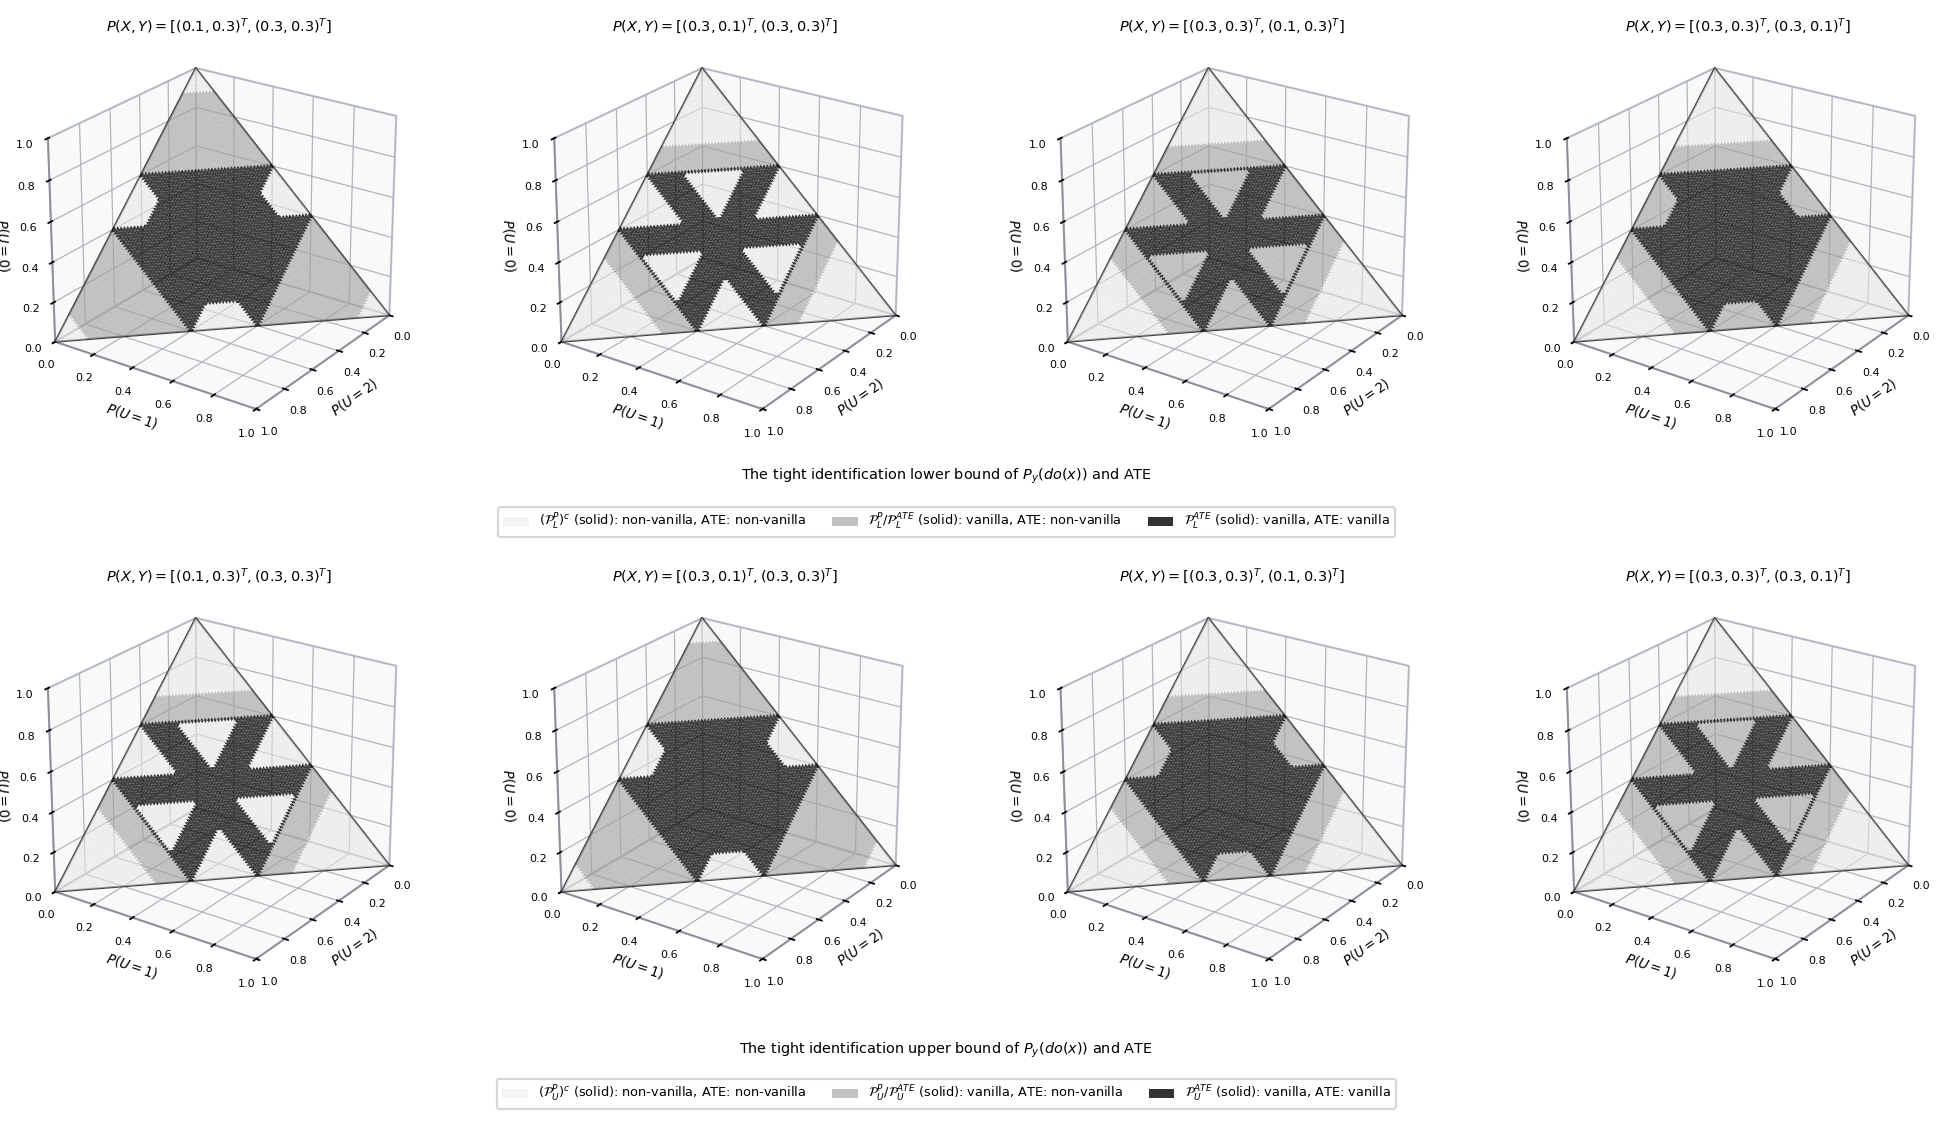

In [22]:
def subset_spectrum_values(p_u):
    return all_subset_sums(np.asarray(p_u, dtype=float))


def exists_subset_in_interval(p_u, lo, hi):
    s = subset_spectrum_values(p_u)
    return bool(((s >= lo - 1e-12) & (s <= hi + 1e-12)).any())


def exists_disjoint_masses_in_intervals(p_u, interval0, interval1):
    p_u = np.asarray(p_u, dtype=float)
    du = len(p_u)
    for code in range(3 ** du):
        tmp = code
        m0 = 0.0
        m1 = 0.0
        for i in range(du):
            assignment = tmp % 3
            tmp //= 3
            if assignment == 1:
                m0 += p_u[i]
            elif assignment == 2:
                m1 += p_u[i]
        if interval0[0] - 1e-12 <= m0 <= interval0[1] + 1e-12 and interval1[0] - 1e-12 <= m1 <= interval1[1] + 1e-12:
            return True
    return False


def classify_simplex_point(p_u, pxy, bound="lower"):
    # pxy is displayed as [(p11,p10)^T, (p01,p00)^T].
    p11 = pxy[0, 0]
    p10 = pxy[0, 1]
    p01 = pxy[1, 0]
    p00 = pxy[1, 1]
    px1 = p11 + p10
    px0 = p01 + p00

    if bound == "lower":
        p_vanilla = exists_subset_in_interval(p_u, p11, px1)
        ate_vanilla = exists_disjoint_masses_in_intervals(p_u, (p00, px0), (p11, px1))
    else:
        p_vanilla = exists_subset_in_interval(p_u, px0, 1.0 - p10)
        ate_vanilla = exists_disjoint_masses_in_intervals(p_u, (p10, px1), (p01, px0))

    if not p_vanilla:
        return 0
    if not ate_vanilla:
        return 1
    return 2


def simplex_grid_arrays(step=0.0125):
    vals = np.arange(0, 1 + 1e-12, step)
    u1, u2 = np.meshgrid(vals, vals, indexing="ij")
    u0 = 1.0 - u1 - u2
    valid = u0 >= -1e-12
    u0 = np.where(valid, np.clip(u0, 0, 1), np.nan)
    return u0, u1, u2, valid


def classify_grid(u0, u1, u2, valid, pxy, bound):
    cls = np.full(u0.shape, -1, dtype=int)
    rows, cols = np.where(valid)
    for r, c in zip(rows, cols):
        cls[r, c] = classify_simplex_point(np.array([u0[r, c], u1[r, c], u2[r, c]]), pxy, bound=bound)
    return cls


def setup_pdf_like_3d_axis(ax):
    vertices = np.array([
        [0, 0, 1],
        [1, 0, 0],
        [0, 1, 0],
        [0, 0, 1],
    ])
    # axes are x=P(U=2), y=P(U=1), z=P(U=0)
    ax.plot(vertices[:, 2], vertices[:, 1], vertices[:, 0], color="#111111", linewidth=0.9, alpha=0.8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_zlim(0, 1)
    ax.set_box_aspect((1, 1, 0.9))
    ax.view_init(elev=24, azim=35)
    ticks = np.linspace(0, 1, 6)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_zticks(ticks)
    ax.tick_params(labelsize=5, pad=-2)
    ax.set_xlabel(r"$P(U=2)$", fontsize=6, labelpad=-8)
    ax.set_ylabel(r"$P(U=1)$", fontsize=6, labelpad=-8)
    ax.set_zlabel(r"$P(U=0)$", fontsize=6, labelpad=-8)
    ax.grid(True)
    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis.pane.set_facecolor((0.96, 0.96, 0.96, 0.20))
        axis.pane.set_edgecolor("#9ca3af")
        axis._axinfo["grid"].update(color="#aeb4bd", linewidth=0.55, linestyle="-")
    ax.xaxis.line.set_color("#8b8f97")
    ax.yaxis.line.set_color("#8b8f97")
    ax.zaxis.line.set_color("#8b8f97")


def triangles_by_class(u0, u1, u2, valid, cls):
    triangles = {0: [], 1: [], 2: []}
    n_rows, n_cols = u0.shape

    def pt(r, c):
        # axes are x=P(U=2), y=P(U=1), z=P(U=0)
        return [float(u2[r, c]), float(u1[r, c]), float(u0[r, c])]

    for r in range(n_rows - 1):
        for c in range(n_cols - 1):
            candidates = [
                ((r, c), (r + 1, c), (r, c + 1)),
                ((r + 1, c), (r + 1, c + 1), (r, c + 1)),
            ]
            for tri in candidates:
                if not all(valid[rr, cc] for rr, cc in tri):
                    continue
                tri_classes = [int(cls[rr, cc]) for rr, cc in tri]
                counts = np.bincount(tri_classes, minlength=3)
                class_id = int(np.argmax(counts))
                triangles[class_id].append([pt(rr, cc) for rr, cc in tri])
    return triangles


def add_triangle_collection(ax, triangles, class_id, color, alpha):
    from mpl_toolkits.mplot3d.art3d import Poly3DCollection

    collection = Poly3DCollection(
        triangles[class_id],
        facecolors=color,
        edgecolors=(0.08, 0.08, 0.08, 0.10),
        linewidths=0.035,
        alpha=alpha,
    )
    ax.add_collection3d(collection)


def plot_figure6(step=0.01):
    pxy_settings = [
        np.array([[0.1, 0.3], [0.3, 0.3]]),
        np.array([[0.3, 0.1], [0.3, 0.3]]),
        np.array([[0.3, 0.3], [0.1, 0.3]]),
        np.array([[0.3, 0.3], [0.3, 0.1]]),
    ]
    titles = [
        r"$P(X,Y)=[(0.1,0.3)^T,(0.3,0.3)^T]$",
        r"$P(X,Y)=[(0.3,0.1)^T,(0.3,0.3)^T]$",
        r"$P(X,Y)=[(0.3,0.3)^T,(0.1,0.3)^T]$",
        r"$P(X,Y)=[(0.3,0.3)^T,(0.3,0.1)^T]$",
    ]
    colors = ["#eeeeee", "#a9a9a9", "#171717"]
    alphas = [0.62, 0.70, 0.88]
    u0, u1, u2, valid = simplex_grid_arrays(step)

    fig = plt.figure(figsize=(13.4, 7.6))
    axes = []
    for row, bound in enumerate(["lower", "upper"]):
        for col, pxy in enumerate(pxy_settings):
            ax = fig.add_subplot(2, 4, row * 4 + col + 1, projection="3d")
            axes.append(ax)
            cls = classify_grid(u0, u1, u2, valid, pxy, bound=bound)
            triangles = triangles_by_class(u0, u1, u2, valid, cls)
            for class_id, color, alpha in [(0, colors[0], alphas[0]), (1, colors[1], alphas[1]), (2, colors[2], alphas[2])]:
                add_triangle_collection(ax, triangles, class_id, color, alpha)
            setup_pdf_like_3d_axis(ax)
            ax.set_title(titles[col], fontsize=6.5, pad=1)

    fig.subplots_adjust(left=0.045, right=0.985, top=0.91, bottom=0.13, wspace=0.02, hspace=0.38)

    from matplotlib.patches import Patch
    lower_handles = [
        Patch(facecolor=colors[0], alpha=alphas[0], label=r"$(\mathcal{P}^{P}_{L})^c$ (solid): non-vanilla, ATE: non-vanilla"),
        Patch(facecolor=colors[1], alpha=alphas[1], label=r"$\mathcal{P}^{P}_{L}/\mathcal{P}^{ATE}_{L}$ (solid): vanilla, ATE: non-vanilla"),
        Patch(facecolor=colors[2], alpha=alphas[2], label=r"$\mathcal{P}^{ATE}_{L}$ (solid): vanilla, ATE: vanilla"),
    ]
    upper_handles = [
        Patch(facecolor=colors[0], alpha=alphas[0], label=r"$(\mathcal{P}^{P}_{U})^c$ (solid): non-vanilla, ATE: non-vanilla"),
        Patch(facecolor=colors[1], alpha=alphas[1], label=r"$\mathcal{P}^{P}_{U}/\mathcal{P}^{ATE}_{U}$ (solid): vanilla, ATE: non-vanilla"),
        Patch(facecolor=colors[2], alpha=alphas[2], label=r"$\mathcal{P}^{ATE}_{U}$ (solid): vanilla, ATE: vanilla"),
    ]
    fig.text(0.5, 0.548, r"The tight identification lower bound of $P_y(do(x))$ and ATE", ha="center", va="center", fontsize=6.5)
    fig.legend(handles=lower_handles, frameon=True, fontsize=5.8, loc="center", bbox_to_anchor=(0.50, 0.510), ncol=3)
    fig.text(0.5, 0.076, r"The tight identification upper bound of $P_y(do(x))$ and ATE", ha="center", va="center", fontsize=6.5)
    fig.legend(handles=upper_handles, frameon=True, fontsize=5.8, loc="center", bbox_to_anchor=(0.50, 0.040), ncol=3)
    save_figure(fig, "figure6_simplex_reproduction", dpi=260)
    return fig, np.array(axes).reshape(2, 4)

plot_figure6(step=0.01)
plt.show()

## O.2 Interpretation Summary

Table 6 reports event-level bounds from binary recoding plus exact Theorem 10 subset enumeration. Table 7 reports only binary ATE contrasts; its Proposition 12 column is the closed-form distance-based valid ATE bound, not a joint-compatible optimization result and not an intersection with Table 6.

In [ ]:
experiment_notes = """Synthetic O.1:
Figure 5 uses U ~ Dir([0.1,0.1,0.1,0.1,0.1]) with d_u=5 and counts a Monte Carlo sample as non-vanilla if any of the four queries P(Y=y | do(X=x)), x,y in {0,1}, is non-vanilla. The entropy-binned experiment evaluates the information loss of entropy summaries H(U) in bits, with the H(U)=1 cutoff used for Figure 5. It is not a test of the large-d_u degeneration result in Proposition 9.

Table 6:
Event-level bounds are computed by first binary-recoding each multi-valued query as E=1{X=x}, F=1{Y in A}, then applying Theorem 10 with exact subset enumeration. Since the confounder support is small in these real-data recodings, we enumerate all subset masses and compute the event-level TPI bounds exactly.

Table 7:
Table 7 reports only binary ATE contrasts and strictly uses Proposition 12's distance-based valid bound: [L_vanilla + max{alpha_1 Delta_11^2 + alpha_0 Delta_00^2, Delta_ATE_L^2/d_u}, U_vanilla - max{alpha_0 Delta_01^2 + alpha_1 Delta_10^2, Delta_ATE_U^2/d_u}]. The INSURANCE rows were reconstructed as treatment contrasts for fixed outcome events, because the original same-treatment signed outcome contrasts are not binary ATEs and are not Proposition 12 estimands.
"""

(OUTPUT_DIR / "experiment_notes_for_paper.txt").write_text(experiment_notes, encoding="utf-8")

print("All experiments completed.")
print(f"Saved figures to {FIG_DIR}")
print(f"Saved tables to {TABLE_DIR}")
print("Key outputs:")
print("- synthetic_entropy_summary.csv")
print("- table6_event_bounds.csv")
print("- table7_prop12_ate_bounds.csv")
print("- table7_prop12_diagnostics.csv")
print("- figure5_nonvanilla_counts.png")
print("- information_loss_entropy_baseline.png")
print("- table7_prop12_width_comparison.png")